In [ ]:
file_path = '/content/drive/MyDrive/teste banco de dados.xlsx'
print(f"Tentando carregar o arquivo de: {file_path}")

Tentando carregar o arquivo de: /content/drive/MyDrive/teste banco de dados.xlsx


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# 1. CARREGAR OS DADOS
df_temp = pd.read_excel(file_path, header=None)
header_row = df_temp[df_temp.apply(lambda x: x.astype(str).str.contains("Tipo do concreto", case=False, na=False)).any(axis=1)].index[0]
df = pd.read_excel(file_path, header=header_row)
df = df.dropna(axis=1, how="all")

In [ ]:
# A variável 'file_path' já está definida:
print(f"O 'file_path' atual é: {file_path}")

O 'file_path' atual é: /content/drive/MyDrive/teste banco de dados.xlsx


In [ ]:
print(df.head())

  Tipo do concreto  fck (resistência)            [MPa]  \
0       AM-0.4-EH1                               61.30   
1       AM-0.8-EH1                               63.80   
2       AM-0.4-EH2                               63.60   
3       AM-0.8-EH2                               58.70   
4       AM-0.4-EH1                               61.30   

   l (comprimento)            [mm]  d (diâmetro            [mm]  \
0                               35                         0.55   
1                               35                         0.55   
2                               60                         0.90   
3                               60                         0.90   
4                               35                         0.55   

   l/d      (fator de forma               Teor de fibra (%)  N (ganchos)  \
0                                  63.64               0.40         1.00   
1                                  63.64               0.80         1.00   
2                   

In [ ]:
print('O diretório de trabalho atual é:')
!pwd

O diretório de trabalho atual é:
/content


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Por favor, verifique o caminho correto para o seu arquivo no Google Drive.
# Geralmente, arquivos na raiz do seu Drive estão em '/content/drive/MyDrive/nome_do_arquivo.xlsx'
# Se estiver em uma subpasta, o caminho seria '/content/drive/MyDrive/Pasta/nome_do_arquivo.xlsx'

file_path = '/content/drive/MyDrive/teste banco de dados.xlsx'
print(f"Tentando carregar o arquivo de: {file_path}")

Tentando carregar o arquivo de: /content/drive/MyDrive/teste banco de dados.xlsx


In [ ]:
# 2. DEFINIR FEATURES E TARGET
feature_cols = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]
target_col = 'fR,1 (N/mm²)      (experimental)'

X = df[feature_cols].values
y = df[target_col].values

# 3. DIVIDIR TREINO/TESTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. NORMALIZAR DADOS PARA TREINAMENTO DNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# 5. TREINAR DNN
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='linear')
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
history = model.fit(X_train_scaled, y_train, validation_split=0.2, epochs=200, batch_size=16, verbose=1)

# Avaliar DNN
loss, mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"DNN - MAE: {mae:.4f}, Loss (MSE): {loss:.4f}")

Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 29.4024 - mae: 4.8540 - val_loss: 23.8046 - val_mae: 4.2253
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 21.4967 - mae: 3.9416 - val_loss: 14.8953 - val_mae: 3.1423
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 11.8661 - mae: 2.7157 - val_loss: 8.6419 - val_mae: 2.3434
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6.6801 - mae: 2.0279 - val_loss: 6.5442 - val_mae: 2.0866
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.7303 - mae: 1.9025 - val_loss: 6.1109 - val_mae: 2.0587
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.1102 - mae: 1.7916 - val_loss: 5.2656 - val_mae: 1.8709
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.0466 - mae: 1.3808 - val_loss: 4.8356 - val_mae: 1.7607
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.4466 - mae: 1.4020 - val_loss: 4.5366 - val_mae: 1.6672
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - los

In [ ]:
# 6. GERAR PREVISÕES DA DNN PARA TODO DATASET (unidades originais)
X_scaled_full = scaler.transform(X)
y_pred_dnn_full = model.predict(X_scaled_full).flatten()

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [ ]:
# 2. DEFINIR FEATURES E TARGET (fR,1)

feature_cols = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]

target_col = 'fR,1 (N/mm²)      (experimental)'

X = df[feature_cols].values
y = df[target_col].values


In [ ]:
# 3. DIVISÃO TREINO / TESTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [ ]:
# 4. NORMALIZAÇÃO DOS DADOS
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# 5. DEFINIÇÃO DA DNN

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='linear')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)


In [ ]:
# 7. AVALIAÇÃO DA DNN — fR,1

y_pred_dnn = model.predict(X_test_scaled).flatten()

mae = mean_absolute_error(y_test, y_pred_dnn)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_dnn))
r2 = r2_score(y_test, y_pred_dnn)

print("DNN — fR,1")
print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2:.4f}")



2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
DNN — fR,1
MAE  = 5.1103
RMSE = 5.7169
R²   = -3.8042


In [ ]:
# 2. DEFINIR FEATURES E TARGET (fR,3)

feature_cols = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]

target_col = 'fR,3 (N/mm²)      (experimental)'

X = df[feature_cols].values
y = df[target_col].values


In [ ]:
# 3. DIVISÃO TREINO / TESTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [ ]:
# 4. NORMALIZAÇÃO DOS DADOS
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# 5. DEFINIÇÃO DA DNN

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='linear')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)


In [ ]:
# 6. TREINAMENTO
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    verbose=1
)


Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 33.3852 - mae: 5.0904 - val_loss: 26.2927 - val_mae: 4.2346
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 21.1292 - mae: 3.7237 - val_loss: 17.2237 - val_mae: 3.2225
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 14.0798 - mae: 2.9094 - val_loss: 10.1309 - val_mae: 2.5462
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 7.1127 - mae: 2.1283 - val_loss: 7.8066 - val_mae: 2.3302
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 6.0532 - mae: 1.9685 - val_loss: 7.2170 - val_mae: 2.2423
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 4.6941 - mae: 1.7119 - val_loss: 6.8252 - val_mae: 2.1771
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.5361 - mae: 1.8108 - val_loss: 6.3064 - val_mae: 2.0721
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5.0205 - mae: 1.8146 - val_loss: 6.0153 - val_mae: 2.0089
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

In [ ]:
# 7. AVALIAÇÃO DA DNN — fR,3

y_pred_dnn = model.predict(X_test_scaled).flatten()

mae = mean_absolute_error(y_test, y_pred_dnn)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_dnn))
r2 = r2_score(y_test, y_pred_dnn)

print("DNN — fR,3")
print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2:.4f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
DNN — fR,3
MAE  = 0.9588
RMSE = 1.4286
R²   = 0.7133


In [ ]:
# 7. TREINAR REGRESSÃO LINEAR SOBRE AS PREVISÕES DA DNN (unidades originais)
lin_approx = LinearRegression()
lin_approx.fit(X, y_pred_dnn_full)

intercept_approx = lin_approx.intercept_
coefs_approx = lin_approx.coef_

# Criar string legível da equação
equacao_str = f"fR = {intercept_approx:.5f}"
for c, f in zip(coefs_approx, feature_cols):
    equacao_str += f" + ({c:.5f} * {f})"

print("Equação linear aproximada da DNN (unidades originais):")
print(equacao_str)

Equação linear aproximada da DNN (unidades originais):
fR = -7.06662 + (0.06893 * fck (resistência)            [MPa]) + (-0.05690 * l (comprimento)            [mm]) + (3.21428 * d (diâmetro            [mm]) + (0.07392 * l/d      (fator de forma             ) + (6.37733 * Teor de fibra (%)) + (0.83283 * N (ganchos))


In [ ]:
# 8. FUNÇÃO PARA CALCULAR fR COM EQUAÇÃO LINEAR APROXIMADA (unidades originais)
def calcular_fr(**kwargs):
    vals = np.array([kwargs[f] for f in feature_cols])
    return float(intercept_approx + np.dot(coefs_approx, vals))

print('Função calcular_fr habilitada.')

Função calcular_fr habilitada.


In [ ]:
# 9. TESTAR EXEMPLO
valores_exemplo = {
    'fck (resistência)            [MPa]': 61.3,
    'l (comprimento)            [mm]': 35,
    'd (diâmetro            [mm]': 0.55,
    'l/d      (fator de forma             ': 63.64,
    'Teor de fibra (%)': 0.4,
    'N (ganchos)': 1
}
fR_previsto = calcular_fr(**valores_exemplo)
print(f'Valor previsto de fR = {fR_previsto:.4f}')

Valor previsto de fR = 5.0235


In [ ]:
# 10. APLICAR A EQUAÇÃO EM TODO DATASET E COMPARAR
preds_approx = np.array([calcular_fr(**{f: row[f] for f in feature_cols}) for idx, row in df.iterrows()])

comparacao = df.copy()
comparacao['fR_previsto'] = preds_approx
print(comparacao[[target_col, 'fR_previsto']].head(10))

mse = mean_squared_error(df[target_col].values, preds_approx)
mae = mean_absolute_error(df[target_col].values, preds_approx)
r2 = r2_score(df[target_col].values, preds_approx)

print(f"\nMSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

   fR,3 (N/mm²)      (experimental)  fR_previsto
0                              3.32         5.02
1                              5.68         7.75
2                              5.53         5.11
3                              8.78         7.32
4                              3.03         5.02
5                              3.28         5.02
6                              2.98         5.02
7                              3.06         5.02
8                              3.50         5.02
9                              4.09         5.02

MSE: 2.9641
MAE: 1.3879
R²: 0.6199


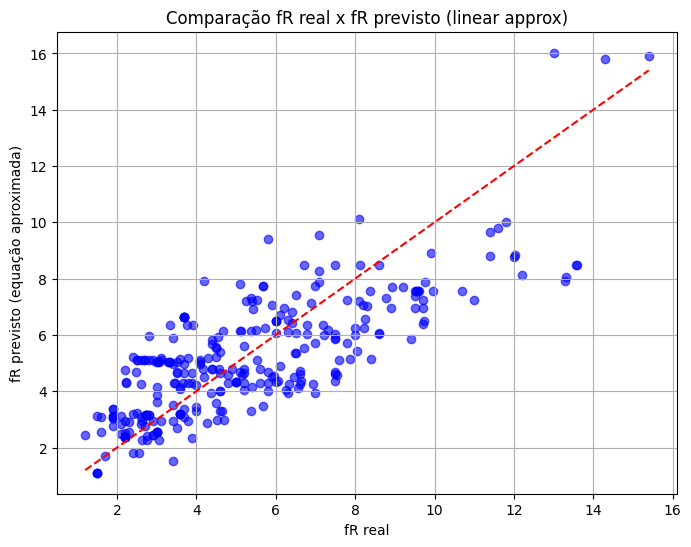

In [ ]:
# 11. GRÁFICO fR REAL X fR PREVISTO
plt.figure(figsize=(8,6))
plt.scatter(df[target_col].values, preds_approx, alpha=0.6, color='blue')
plt.plot([df[target_col].min(), df[target_col].max()], [df[target_col].min(), df[target_col].max()], 'r--')
plt.xlabel('fR real')
plt.ylabel('fR previsto (equação aproximada)')
plt.title('Comparação fR real x fR previsto (linear approx)')
plt.grid(True)
plt.show()

Comparação com erro absoluto:
   fR,3 (N/mm²)      (experimental)  fR_previsto  Erro_absoluto
0                              3.32         5.02           1.70
1                              5.68         7.75           2.07
2                              5.53         5.11           0.42
3                              8.78         7.32           1.46
4                              3.03         5.02           1.99
5                              3.28         5.02           1.74
6                              2.98         5.02           2.04
7                              3.06         5.02           1.96
8                              3.50         5.02           1.52
9                              4.09         5.02           0.93

Estatísticas do erro absoluto:
count   291.00
mean      1.39
std       1.02
min       0.00
25%       0.52
50%       1.17
75%       2.02
max       5.37
Name: Erro_absoluto, dtype: float64


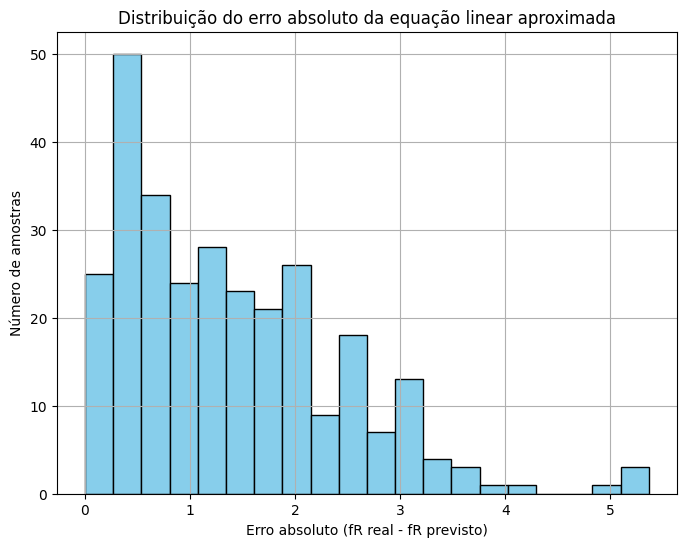

In [ ]:
# 12. AVALIAÇÃO DETALHADA DO ERRO POR LINHA

# Calcular erro absoluto por linha
comparacao['Erro_absoluto'] = np.abs(comparacao[target_col] - comparacao['fR_previsto'])

# Mostrar as primeiras 10 linhas com erro
print("Comparação com erro absoluto:")
print(comparacao[[target_col, 'fR_previsto', 'Erro_absoluto']].head(10))

# Estatísticas gerais do erro
print("\nEstatísticas do erro absoluto:")
print(comparacao['Erro_absoluto'].describe())

# Plotar histograma do erro absoluto
plt.figure(figsize=(8,6))
plt.hist(comparacao['Erro_absoluto'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Erro absoluto (fR real - fR previsto)')
plt.ylabel('Número de amostras')
plt.title('Distribuição do erro absoluto da equação linear aproximada')
plt.grid(True)
plt.show()


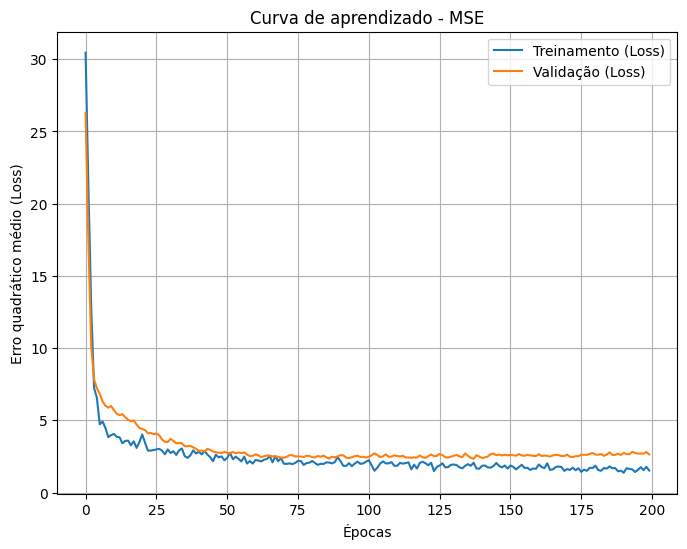

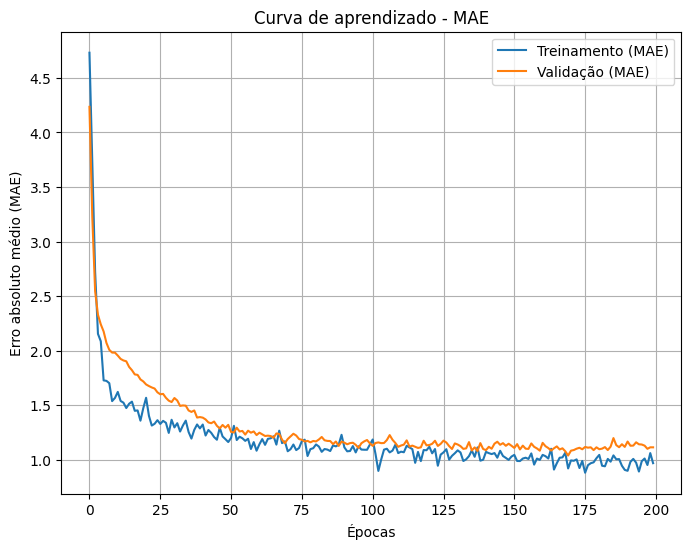

In [ ]:
# 13. CURVAS DE TREINAMENTO DA DNN

import matplotlib.pyplot as plt

# Curva de aprendizado - Loss (MSE)
plt.figure(figsize=(8,6))
plt.plot(history.history['loss'], label='Treinamento (Loss)')
plt.plot(history.history['val_loss'], label='Validação (Loss)')
plt.title('Curva de aprendizado - MSE')
plt.xlabel('Épocas')
plt.ylabel('Erro quadrático médio (Loss)')
plt.legend()
plt.grid(True)
plt.show()

# Curva de aprendizado - MAE
plt.figure(figsize=(8,6))
plt.plot(history.history['mae'], label='Treinamento (MAE)')
plt.plot(history.history['val_mae'], label='Validação (MAE)')
plt.title('Curva de aprendizado - MAE')
plt.xlabel('Épocas')
plt.ylabel('Erro absoluto médio (MAE)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
!pip install lazypredict

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from lazypredict.Supervised import LazyClassifier

import warnings
warnings.filterwarnings('ignore')

CARREGANDO E PREPARANDO OS DADOS
Cabeçalho encontrado na linha: 5

Colunas disponíveis (12):
    0. 'Tipo do concreto'
    1. 'fck (resistência)            [MPa]'
    2. 'l (comprimento)            [mm]'
    3. 'd (diâmetro            [mm]'
    4. 'l/d      (fator de forma'
    5. 'Teor de fibra (%)'
    6. 'N (ganchos)'
    7. 'fR,1 (N/mm²)      (experimental)'
    8. 'fR,3 (N/mm²)      (experimental)'
    9. 'Unnamed: 13'
   10. 'Unnamed: 14'
   11. 'Unnamed: 15'

Colunas identificadas:
  Target (fR,1): fR,1 (N/mm²)      (experimental)
  fck: fck (resistência)            [MPa]
  l: l (comprimento)            [mm]
  d: d (diâmetro            [mm]
  l/d: l/d      (fator de forma
  Teor de fibra: Teor de fibra (%)
  N ganchos: N (ganchos)
  Tipo: Tipo do concreto

DataFrame criado com 291 linhas e 7 colunas

Convertendo dados para numérico...

Removidas 0 linhas com valores NaN
Dados finais: 291 amostras

ESTATÍSTICAS DO DATASET:
  Amostras: 291
  Features: 6

ESTATÍSTICAS DO TARGET 'fR

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 119, number of negative: 113
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000178 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 122
[LightGBM] [Info] Number of data points in the train set: 232, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.512931 -> initscore=0.051736
[LightGBM] [Info] Start training from score 0.051736
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

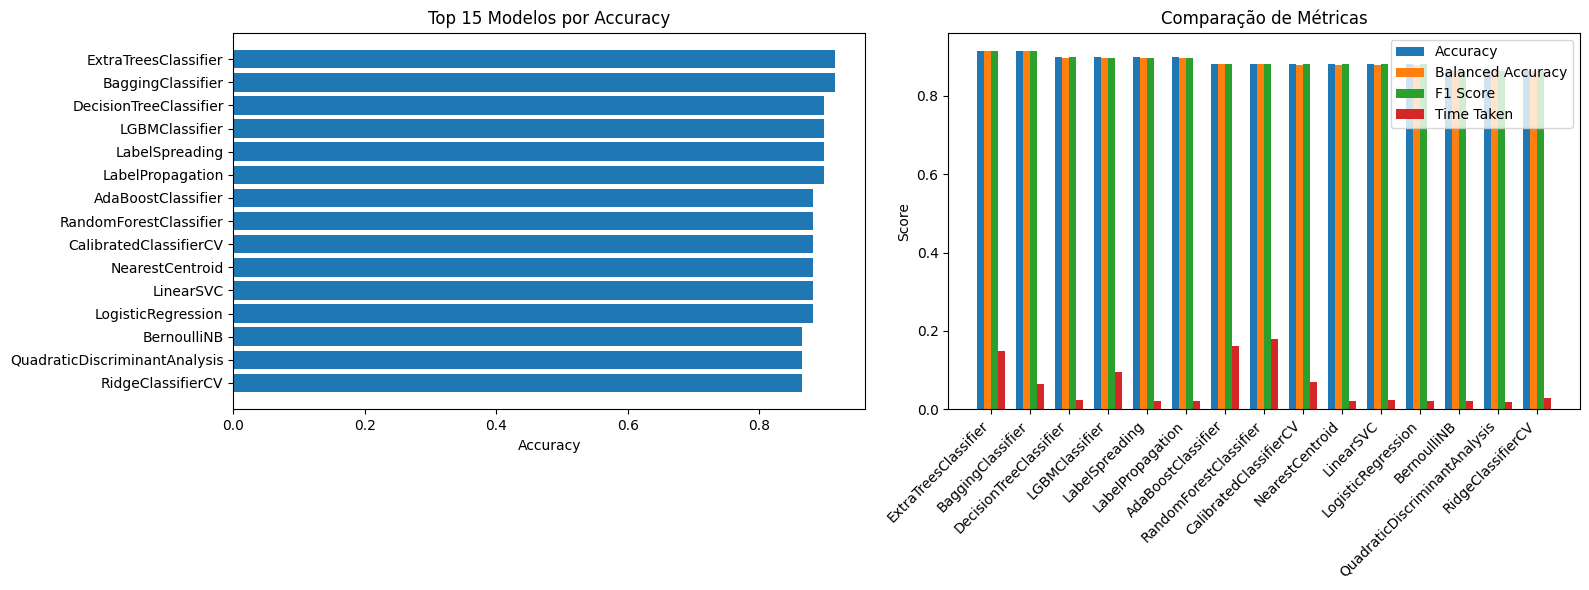


Matriz de confusão para: ExtraTreesClassifier
Modelo 'ExtraTreesClassifier' não encontrado

ANÁLISE DE CORRELAÇÃO


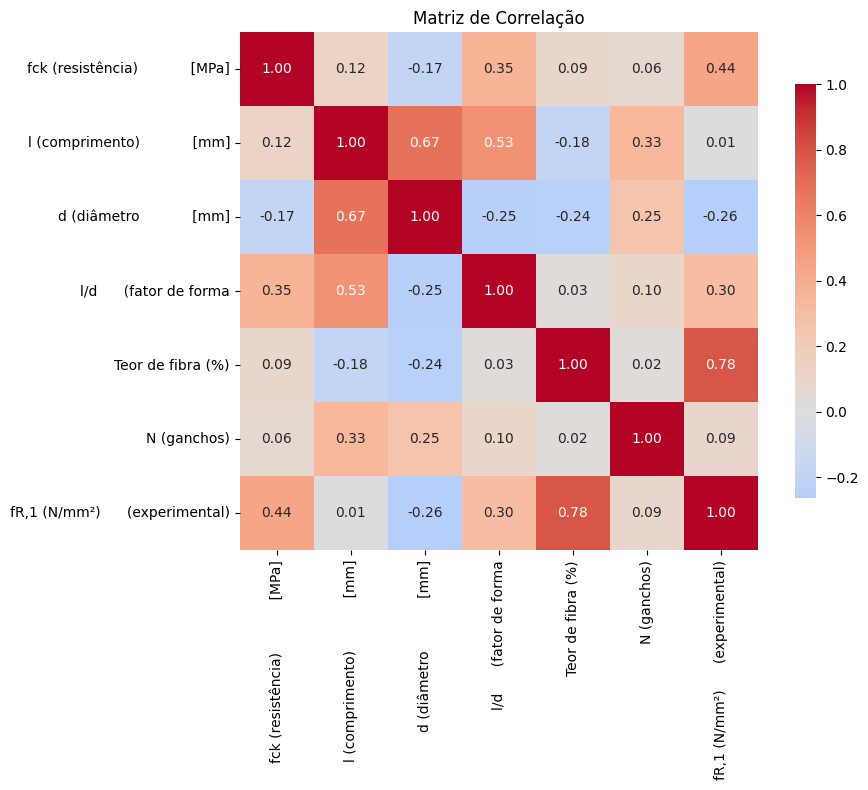


CORRELAÇÃO COM fR,1:
   Teor de fibra (%): 0.7818 (ALTA correlação positiva)
   fck (resistência)            [MPa]: 0.4448 (MÉDIA correlação positiva)
   l/d      (fator de forma: 0.2991 (BAIXA correlação positiva)
   N (ganchos): 0.0944 (BAIXA correlação positiva)
   l (comprimento)            [mm]: 0.0064 (BAIXA correlação positiva)
   d (diâmetro            [mm]: -0.2641 (BAIXA correlação negativa)

RESUMO FINAL

MELHOR MODELO: ExtraTreesClassifier
   Accuracy: 0.9153
   Balanced Accuracy: 0.9149
   F1 Score: 0.9152
   Time Taken: 0.1495

DISTRIBUIÇÃO DAS CLASSES:
   Low_fR1: 149 amostras (51.2%)
   High_fR1: 142 amostras (48.8%)

INFORMAÇÕES TÉCNICAS:
   Total de amostras: 291
   Features usadas: 6
   Tamanho treino: 232
   Tamanho teste: 59

SALVANDO RESULTADOS...
Resultados salvos em 'resultados_concreto.csv'
Resultados salvos em 'resultados_concreto.xlsx'
Dados processados salvos em 'dados_concreto_processados.csv'

ANÁLISE CONCLUÍDA

ESTATÍSTICAS DESCRITIVAS COMPLETAS:
       

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from lazypredict.Supervised import LazyClassifier

import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CARREGAR E PREPARAR OS DADOS - VERSÃO AJUSTADA
# ============================================================================

print("=" * 80)
print("CARREGANDO E PREPARANDO OS DADOS")
print("=" * 80)

# Carregar dados brutos para encontrar o cabeçalho correto
df_raw = pd.read_excel(file_path, header=None)

# Encontrar a linha com "Tipo do concreto"
header_idx = None
for i in range(min(20, len(df_raw))):  # Verificar as primeiras 20 linhas
    if df_raw.iloc[i].astype(str).str.contains("Tipo do concreto", case=False, na=False).any():
        header_idx = i
        break

if header_idx is None:
    raise ValueError("Cabeçalho 'Tipo do concreto' não encontrado!")

print(f"Cabeçalho encontrado na linha: {header_idx}")

# Carregar dados com cabeçalho correto
df = pd.read_excel(file_path, header=header_idx)
df = df.dropna(axis=1, how="all")

# Limpar nomes das colunas
df.columns = df.columns.str.strip()

# Mostrar informações sobre as colunas
print(f"\nColunas disponíveis ({len(df.columns)}):")
for i, col in enumerate(df.columns):
    print(f"  {i:3d}. '{col}'")

# ============================================================================
# IDENTIFICAR COLUNAS IMPORTANTES
# ============================================================================

# Mapear possíveis nomes de colunas
col_mapping = {
    'fck': ['fck', 'fck (resistência)', 'fck             [MPa]'],
    'l': ['l (comprimento)', 'l             [mm]', 'comprimento'],
    'd': ['d (diâmetro', 'd             [mm]', 'diâmetro'],
    'l/d': ['l/d', 'l/d      (fator de forma             '],
    'fibra': ['Teor de fibra (%)', 'Teor de fibra'],
    'ganchos': ['N (ganchos)', 'ganchos'],
    'fR1': ['fR,1 (N/mm²)      (experimental)', 'fR,1', 'fR1'],
    'fR3': ['fR,3 (N/mm²)      (experimental)', 'fR,3', 'fR3'],
    'tipo': ['Tipo do concreto', 'Tipo']
}

# Função para encontrar coluna
def find_column(possible_names):
    for name in possible_names:
        for col in df.columns:
            if name.lower() in str(col).lower():
                return col
    return None

# Encontrar colunas
target_col = find_column(col_mapping['fR1'])
fck_col = find_column(col_mapping['fck'])
l_col = find_column(col_mapping['l'])
d_col = find_column(col_mapping['d'])
ld_col = find_column(col_mapping['l/d'])
fibra_col = find_column(col_mapping['fibra'])
ganchos_col = find_column(col_mapping['ganchos'])
tipo_col = find_column(col_mapping['tipo'])

print(f"\nColunas identificadas:")
print(f"  Target (fR,1): {target_col}")
print(f"  fck: {fck_col}")
print(f"  l: {l_col}")
print(f"  d: {d_col}")
print(f"  l/d: {ld_col}")
print(f"  Teor de fibra: {fibra_col}")
print(f"  N ganchos: {ganchos_col}")
print(f"  Tipo: {tipo_col}")

# ============================================================================
# CRIAR DATAFRAME PARA ANÁLISE
# ============================================================================

# Verificar se encontramos as colunas necessárias
if not all([target_col, fck_col, l_col, d_col, ld_col, fibra_col, ganchos_col]):
    print("\nAVISO: Algumas colunas não foram encontradas!")
    print("Usando todas as colunas numéricas...")

    # Selecionar apenas colunas numéricas
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    if target_col:
        # Remover target das features se ele for numérico
        if target_col in numeric_cols:
            numeric_cols.remove(target_col)

        feature_cols = numeric_cols
    else:
        print("ERRO: Coluna target não encontrada!")
        # Tentar usar a primeira coluna numérica como target
        if len(numeric_cols) > 0:
            target_col = numeric_cols[0]
            feature_cols = numeric_cols[1:]
            print(f"  Usando '{target_col}' como target")
else:
    # Usar colunas específicas
    feature_cols = [fck_col, l_col, d_col, ld_col, fibra_col, ganchos_col]

# Criar DataFrame de trabalho
if target_col in df.columns:
    concrete_df = df[feature_cols + [target_col]].copy()
else:
    concrete_df = df[feature_cols].copy()
    print("AVISO: Target não incluído no DataFrame")

print(f"\nDataFrame criado com {len(concrete_df)} linhas e {len(concrete_df.columns)} colunas")

# ============================================================================
# LIMPEZA E CONVERSÃO DOS DADOS
# ============================================================================

# Converter todas as colunas para numérico (tratar fórmulas e erros)
print("\nConvertendo dados para numérico...")
for col in concrete_df.columns:
    concrete_df[col] = pd.to_numeric(concrete_df[col], errors='coerce')
    na_count = concrete_df[col].isna().sum()
    if na_count > 0:
        print(f"  {col}: {na_count} valores não numéricos convertidos para NaN")

# Remover linhas com valores NaN
initial_rows = len(concrete_df)
concrete_df = concrete_df.dropna()
final_rows = len(concrete_df)
print(f"\nRemovidas {initial_rows - final_rows} linhas com valores NaN")
print(f"Dados finais: {final_rows} amostras")

# Verificar se temos dados suficientes
if len(concrete_df) < 10:
    print("\nERRO: Dados insuficientes após limpeza!")
    print("Mostrando primeiras linhas para diagnóstico:")
    print(concrete_df.head())
    raise ValueError("Dados insuficientes para análise")

# ============================================================================
# ESTATÍSTICAS INICIAIS
# ============================================================================

print(f"\nESTATÍSTICAS DO DATASET:")
print(f"  Amostras: {len(concrete_df)}")
print(f"  Features: {len(feature_cols)}")

if target_col in concrete_df.columns:
    print(f"\nESTATÍSTICAS DO TARGET '{target_col}':")
    print(f"  Média: {concrete_df[target_col].mean():.4f}")
    print(f"  Mediana: {concrete_df[target_col].median():.4f}")
    print(f"  Mínimo: {concrete_df[target_col].min():.4f}")
    print(f"  Máximo: {concrete_df[target_col].max():.4f}")
    print(f"  Desvio padrão: {concrete_df[target_col].std():.4f}")

# Mostrar primeiras linhas
print(f"\nPRIMEIRAS 5 LINHAS DOS DADOS:")
print(concrete_df.head())

# ============================================================================
# CLASSE CLASSIFICADORA (MANTIDA SUA VERSÃO ORIGINAL)
# ============================================================================

class ConcretePropertiesClassifier:
    def __init__(self, data, target_column, test_size=0.2, random_state=42):
        """
        Classificador para propriedades do concreto com fibras
        """
        self.data = data.copy()
        self.target_column = target_column
        self.test_size = test_size
        self.random_state = random_state

        # Pré-processamento
        self._prepare_target()

        # Separar features e target
        self.features = self.data.drop(self.target_column, axis=1)
        self.targets = self.data[self.target_column]

        # Split dos dados
        self.features_train, self.features_test, self.targets_train, self.targets_test = train_test_split(
            self.features, self.targets,
            test_size=self.test_size,
            random_state=self.random_state,
            stratify=self.targets
        )

        # Inicializar LazyClassifier
        self.lazyClassifier = LazyClassifier(
            verbose=0,
            ignore_warnings=True,
            custom_metric=None,
            random_state=self.random_state
        )
        self.models = None
        self.predictions = None

    def _prepare_target(self):
        """Converter variável contínua em categórica para classificação"""
        if self.target_column in self.data.columns:
            threshold = self.data[self.target_column].median()
            self.data[self.target_column] = np.where(
                self.data[self.target_column] > threshold,
                'High_fR1',
                'Low_fR1'
            )
            print(f"\nTarget convertido para classificação binária")
            print(f"   Threshold (mediana): {threshold:.4f}")
            print(f"   Distribuição: {self.data[self.target_column].value_counts().to_dict()}")
        else:
            print(f"Coluna '{self.target_column}' não encontrada")

    def fit(self):
        """Treinar múltiplos modelos"""
        print("\nTreinando modelos com LazyClassifier...")
        self.models, self.predictions = self.lazyClassifier.fit(
            self.features_train, self.features_test,
            self.targets_train, self.targets_test
        )
        print("Treinamento concluído!")
        return self.models

    def get_models(self):
        """Retornar resultados dos modelos"""
        return self.models

    def get_predictions(self):
        """Retornar predições"""
        return self.predictions

    def plot_confusion_matrix(self, model_name=None):
        """Plotar matriz de confusão"""
        if self.predictions is None:
            print("Treine os modelos primeiro!")
            return

        if model_name is None:
            model_name = self.models.index[0] if self.models is not None else 'Logistic Regression'

        if model_name not in self.predictions.columns:
            print(f"Modelo '{model_name}' não encontrado")
            return

        y_pred = self.predictions[model_name]
        cm = confusion_matrix(self.targets_test, y_pred)

        fig, ax = plt.subplots(figsize=(8, 6))
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=['Low_fR1', 'High_fR1']
        )
        disp.plot(ax=ax, cmap='Blues')
        plt.title(f'Matriz de Confusão - {model_name}')
        plt.show()

    def plot_model_comparison(self, top_n=15):
        """Plotar comparação dos modelos"""
        if self.models is None:
            print("Treine os modelos primeiro!")
            return

        # Filtrar valores None e pegar top_n modelos
        top_models = self.models.head(top_n).copy()

        # Remover colunas com todos valores None
        top_models = top_models.dropna(axis=1, how='all')

        # Substituir valores None restantes por 0 para plotagem
        top_models = top_models.fillna(0)

        if len(top_models.columns) == 0:
            print("Nenhuma métrica disponível para plotar")
            return

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # Gráfico 1: Usar a primeira métrica numérica disponível
        numeric_cols = top_models.select_dtypes(include=[np.number]).columns
        if len(numeric_cols) == 0:
            print("Nenhuma métrica numérica disponível")
            return

        primary_metric = numeric_cols[0]
        axes[0].barh(range(len(top_models)), top_models[primary_metric])
        axes[0].set_yticks(range(len(top_models)))
        axes[0].set_yticklabels(top_models.index)
        axes[0].set_xlabel(primary_metric)
        axes[0].set_title(f'Top {len(top_models)} Modelos por {primary_metric}')
        axes[0].invert_yaxis()

        # Gráfico 2: Comparação de múltiplas métricas numéricas
        metrics_to_plot = numeric_cols[:4]  # Plotar no máximo 4 métricas
        if len(metrics_to_plot) > 1:
            x = np.arange(len(top_models))
            width = 0.18

            for i, metric in enumerate(metrics_to_plot):
                axes[1].bar(x + i*width, top_models[metric], width, label=metric)

            axes[1].set_xticks(x + width*(len(metrics_to_plot)-1)/2)
            axes[1].set_xticklabels(top_models.index, rotation=45, ha='right')
            axes[1].set_ylabel('Score')
            axes[1].set_title('Comparação de Métricas')
            axes[1].legend()
        else:
            axes[1].text(0.5, 0.5, f'Apenas {primary_metric} disponível',
                        ha='center', va='center', fontsize=12)
            axes[1].set_title('Informação de Métricas')
            axes[1].axis('off')

        plt.tight_layout()
        plt.show()

# ============================================================================
# EXECUTAR ANÁLISE
# ============================================================================

if target_col in concrete_df.columns:
    print("\n" + "=" * 80)
    print("INICIANDO ANÁLISE DE CLASSIFICAÇÃO")
    print("=" * 80)

    # Criar e treinar classificador
    concreteClassifier = ConcretePropertiesClassifier(
        data=concrete_df,
        target_column=target_col,
        test_size=0.2,
        random_state=42
    )

    # Treinar
    models = concreteClassifier.fit()

    # ============================================================================
    # MOSTRAR RESULTADOS
    # ============================================================================

    if models is not None:
        # Limpar modelos (remover colunas com todos valores None)
        models_clean = models.copy()
        models_clean = models_clean.dropna(axis=1, how='all')

        print(f"\nCOLUNAS DISPONÍVEIS NOS RESULTADOS:")
        print(models_clean.columns.tolist())

        print(f"\nTOP 10 MODELOS:")

        # Mostrar apenas colunas numéricas
        numeric_cols = models_clean.select_dtypes(include=[np.number]).columns

        if len(numeric_cols) > 0:
            # Ordenar pela primeira métrica numérica disponível
            sort_by = numeric_cols[0]
            top_10 = models_clean.sort_values(sort_by, ascending=False).head(10)

            # Formatar para mostrar 5 casas decimais
            pd.set_option('display.float_format', lambda x: f'{x:.5f}')
            print(top_10[numeric_cols])
        else:
            print("Nenhuma métrica numérica disponível")
            print(models_clean.head(10))

        # Mostrar todos os modelos
        print(f"\nTODOS OS {len(models_clean)} MODELOS TESTADOS:")
        if len(numeric_cols) > 0:
            # Ordenar pela melhor métrica
            all_models_sorted = models_clean.sort_values(numeric_cols[0], ascending=False)
            print(all_models_sorted[numeric_cols])
        else:
            print(models_clean)

        # Plotar gráficos
        print("\nGERANDO GRÁFICOS...")
        concreteClassifier.plot_model_comparison(top_n=15)

        # Matriz de confusão
        if concreteClassifier.predictions is not None:
            best_model_name = models_clean.index[0]
            print(f"\nMatriz de confusão para: {best_model_name}")
            concreteClassifier.plot_confusion_matrix(model_name=best_model_name)

        # ANÁLISE DE CORRELAÇÃO
        print("\n" + "=" * 80)
        print("ANÁLISE DE CORRELAÇÃO")
        print("=" * 80)

        correlation_matrix = concrete_df.corr()

        plt.figure(figsize=(10, 8))
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
                    fmt='.2f', square=True, cbar_kws={"shrink": 0.8})
        plt.title('Matriz de Correlação')
        plt.tight_layout()
        plt.show()

        # Correlação com target
        print("\nCORRELAÇÃO COM fR,1:")
        if target_col in correlation_matrix.columns:
            target_corr = correlation_matrix[target_col].sort_values(ascending=False)
            for feature, corr in target_corr.items():
                if feature != target_col:
                    importance = "ALTA" if abs(corr) > 0.5 else "MÉDIA" if abs(corr) > 0.3 else "BAIXA"
                    direction = "positiva" if corr > 0 else "negativa"
                    print(f"   {feature}: {corr:.4f} ({importance} correlação {direction})")

        # RESUMO FINAL
        print("\n" + "=" * 80)
        print("RESUMO FINAL")
        print("=" * 80)

        if len(numeric_cols) > 0:
            best_model = models_clean.iloc[0]
            print(f"\nMELHOR MODELO: {best_model.name}")

            # Mostrar todas as métricas numéricas disponíveis
            for metric in numeric_cols:
                value = best_model[metric]
                print(f"   {metric}: {value:.4f}")

        # Distribuição das classes
        class_dist = concreteClassifier.data[target_col].value_counts()
        print(f"\nDISTRIBUIÇÃO DAS CLASSES:")
        for cls, count in class_dist.items():
            percentage = (count / len(concreteClassifier.data)) * 100
            print(f"   {cls}: {count} amostras ({percentage:.1f}%)")

        # Informações do dataset
        print(f"\nINFORMAÇÕES TÉCNICAS:")
        print(f"   Total de amostras: {len(concrete_df)}")
        print(f"   Features usadas: {len(feature_cols)}")
        print(f"   Tamanho treino: {len(concreteClassifier.features_train)}")
        print(f"   Tamanho teste: {len(concreteClassifier.features_test)}")

        # Salvar resultados
        print("\nSALVANDO RESULTADOS...")
        models_clean.to_csv('resultados_concreto.csv')
        print("Resultados salvos em 'resultados_concreto.csv'")

        # Salvar também em Excel para melhor formatação
        models_clean.to_excel('resultados_concreto.xlsx')
        print("Resultados salvos em 'resultados_concreto.xlsx'")

        # Salvar dados processados
        concrete_df.to_csv('dados_concreto_processados.csv', index=False)
        print("Dados processados salvos em 'dados_concreto_processados.csv'")

    else:
        print("Nenhum modelo foi treinado")

    print("\n" + "=" * 80)
    print("ANÁLISE CONCLUÍDA")
    print("=" * 80)

    # Mostrar estatísticas descritivas
    print("\nESTATÍSTICAS DESCRITIVAS COMPLETAS:")
    print(concrete_df.describe())

else:
    print("\n" + "=" * 80)
    print("AVISO: ANÁLISE NÃO REALIZADA")
    print("=" * 80)
    print("A coluna target não foi encontrada ou incluída no DataFrame.")
    print("\nColunas disponíveis no DataFrame:")
    for col in concrete_df.columns:
        print(f"  - {col}")

In [ ]:
# ==============================================================================
# CONCRETE FIBER PROPERTIES ANALYZER - CLASSIFICAÇÃO E REGRESSÃO
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from lazypredict.Supervised import LazyClassifier, LazyRegressor
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# FUNÇÕES AUXILIARES (NORMALIZAÇÃO E BUSCA DE COLUNAS)
# ==============================================================================

def normalize_columns(df):
    df = df.copy()
    df.columns = (
        df.columns
        .astype(str)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )
    return df


def find_column(df, contains):
    for col in df.columns:
        if contains.lower() in col.lower():
            return col
    raise ValueError(f"Coluna contendo '{contains}' não encontrada")


# ==============================================================================
# CLASSE PRINCIPAL
# ==============================================================================

class ConcreteFiberAnalyzer:

    def __init__(self, data, target_column, test_size=0.2, random_state=42):

        self.data = data.copy()
        self.data = normalize_columns(self.data)

        self.target_column = target_column
        self.test_size = test_size
        self.random_state = random_state

        # FEATURES DETECTADAS AUTOMATICAMENTE
        self.feature_columns = [
            find_column(self.data, 'fck'),
            find_column(self.data, 'l ('),
            find_column(self.data, 'd ('),
            find_column(self.data, 'l/d'),
            find_column(self.data, 'Teor de fibra'),
            find_column(self.data, 'N (ganchos)')
        ]

        self._prepare_data()

        self.classification_models = None
        self.regression_models = None
        self.regression_predictions = None

    def _prepare_data(self):

        print(" Preparando dados...")

        cols = self.feature_columns + [self.target_column]
        self.data = self.data[cols].copy()

        for col in self.data.columns:
            self.data[col] = pd.to_numeric(self.data[col], errors='coerce')

        n0 = len(self.data)
        self.data.dropna(inplace=True)
        print(f" Removidas {n0 - len(self.data)} linhas com NaN")

        print(f" Dataset final: {len(self.data)} amostras")

    # ==========================================================================
    # CLASSIFICAÇÃO
    # ==========================================================================

    def run_classification(self):

        print("\n" + "="*80)
        print("CLASSIFICAÇÃO HIGH / LOW")
        print("="*80)

        df = self.data.copy()
        threshold = df[self.target_column].median()

        df['Target_class'] = np.where(
            df[self.target_column] > threshold, 'High', 'Low'
        )

        X = df[self.feature_columns]
        y = df['Target_class']

        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=self.test_size,
            random_state=self.random_state,
            stratify=y
        )

        clf = LazyClassifier(verbose=0, ignore_warnings=True)
        self.classification_models, _ = clf.fit(
            X_train, X_test, y_train, y_test
        )

        return self.classification_models

    # ==========================================================================
    # REGRESSÃO
    # ==========================================================================

    def run_regression(self):

        print("\n" + "="*80)
        print("REGRESSÃO")
        print("="*80)

        X = self.data[self.feature_columns]
        y = self.data[self.target_column]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=self.test_size,
            random_state=self.random_state
        )

        reg = LazyRegressor(verbose=0, ignore_warnings=True)
        self.regression_models, self.regression_predictions = reg.fit(
            X_train, X_test, y_train, y_test
        )

        return self.regression_models

    # ==========================================================================
    # PLOTS
    # ==========================================================================

    def plot_regression_results(self, top_n=10):

        if self.regression_models is None:
            return

        top = self.regression_models.head(top_n)

        plt.figure(figsize=(10, 6))
        plt.barh(top.index, top['R-Squared'])
        plt.xlabel('R²')
        plt.title('Top Modelos de Regressão')
        plt.gca().invert_yaxis()
        plt.show()

    # ==========================================================================
    # RELATÓRIO
    # ==========================================================================

    def generate_report(self):

        print("\n" + "="*80)
        print("RELATÓRIO FINAL")
        print("="*80)

        print("\nCorrelação com target:")
        corr = self.data.corr()[self.target_column].sort_values(ascending=False)
        print(corr)

        if self.classification_models is not None:
            best = self.classification_models.iloc[0]
            print(f"\nMelhor Classificador: {best.name}")
            print(f"Accuracy: {best['Accuracy']:.4f}")

        if self.regression_models is not None:
            best = self.regression_models.iloc[0]
            print(f"\nMelhor Regressor: {best.name}")
            print(f"R²: {best['R-Squared']:.4f}")


# ==============================================================================
# PIPELINE COMPLETO
# ==============================================================================

def complete_concrete_analysis(filepath, target_contains):

    print("\n" + "="*80)
    print("ANÁLISE COMPLETA DO CONCRETO COM FIBRAS")
    print("="*80)

    # Identificar header automaticamente
    temp = pd.read_excel(filepath, header=None)
    header_row = temp[temp.apply(
        lambda x: x.astype(str).str.contains("Tipo do concreto", case=False, na=False)
    ).any(axis=1)].index[0]

    df = pd.read_excel(filepath, header=header_row)
    df = normalize_columns(df)

    target_col = find_column(df, target_contains)

    analyzer = ConcreteFiberAnalyzer(
        data=df,
        target_column=target_col
    )

    clf = analyzer.run_classification()
    reg = analyzer.run_regression()

    analyzer.plot_regression_results()
    analyzer.generate_report()

    return analyzer, clf, reg


# ==============================================================================
# EXECUÇÃO
# ==============================================================================

if __name__ == "__main__":

    # fR,1
    analyzer_fR1, clf_fR1, reg_fR1 = complete_concrete_analysis(
        filepath="teste banco de dados.xlsx",
        target_contains="fR,1"
    )

    # fR,3 (se existir)
    try:
        analyzer_fR3, clf_fR3, reg_fR3 = complete_concrete_analysis(
            filepath="teste banco de dados.xlsx",
            target_contains="fR,3"
        )
    except Exception as e:
        print(f"\n fR,3 não disponível: {e}")



ANÁLISE COMPLETA DO CONCRETO COM FIBRAS


FileNotFoundError: [Errno 2] No such file or directory: 'teste banco de dados.xlsx'


ANÁLISE DE REGRESSÃO PARA FR,1
 Preparando dados...
 Removidas 0 linhas com NaN
 Dataset final: 291 amostras

REGRESSÃO


  0%|          | 0/42 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000054 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 125
[LightGBM] [Info] Number of data points in the train set: 232, number of used features: 6
[LightGBM] [Info] Start training from score 5.416343
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

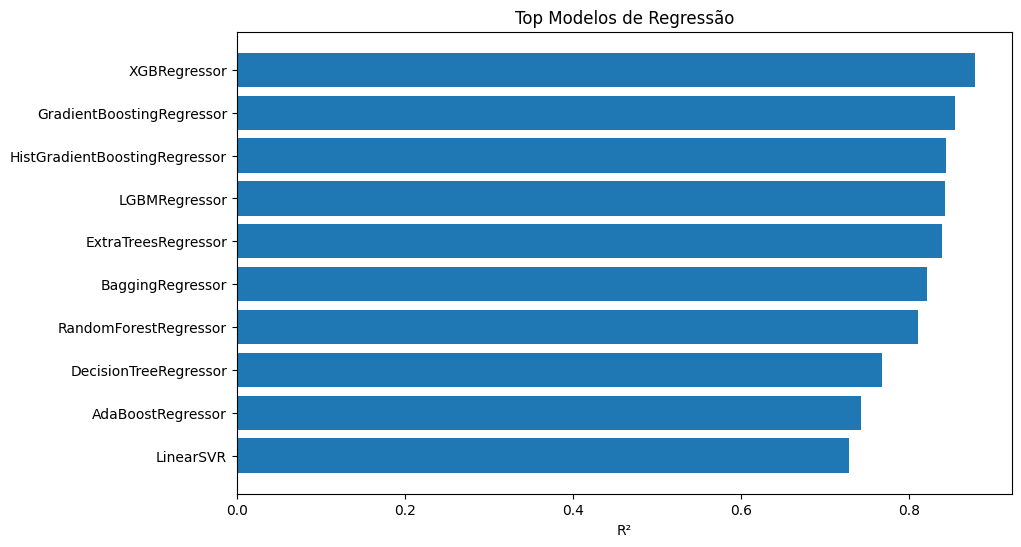


RELATÓRIO FINAL

Correlação com target:
fR,1 (N/mm²) (experimental)    1.00000
Teor de fibra (%)              0.78181
fck (resistência) [MPa]        0.44481
l/d (fator de forma            0.29907
N (ganchos)                    0.09442
l (comprimento) [mm]           0.00638
d (diâmetro [mm]              -0.26406
Name: fR,1 (N/mm²) (experimental), dtype: float64

Melhor Regressor: XGBRegressor
R²: 0.8780

ANÁLISE DE REGRESSÃO PARA FR,3
 Preparando dados...
 Removidas 0 linhas com NaN
 Dataset final: 291 amostras

REGRESSÃO


  0%|          | 0/42 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000062 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 125
[LightGBM] [Info] Number of data points in the train set: 232, number of used features: 6
[LightGBM] [Info] Start training from score 5.379771
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

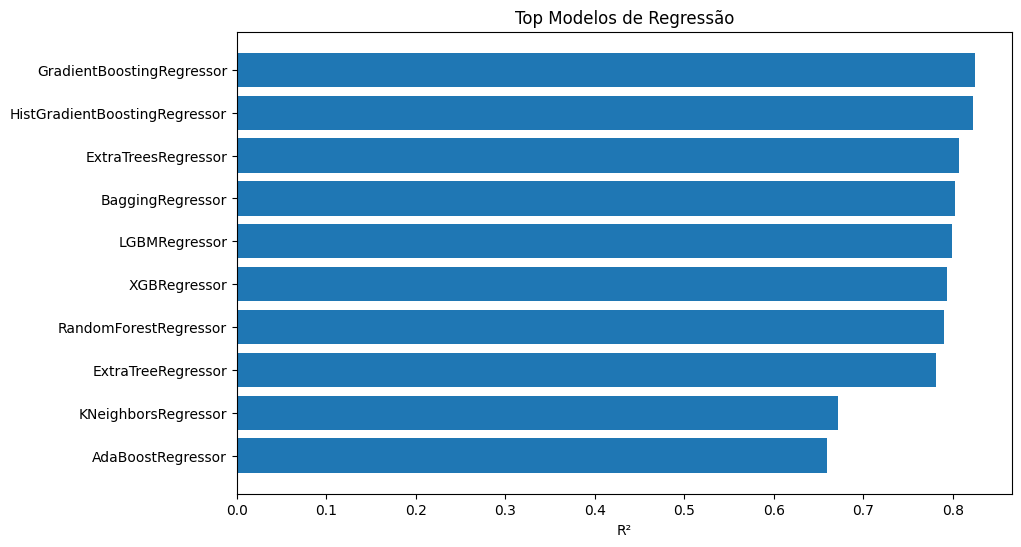


RELATÓRIO FINAL

Correlação com target:
fR,3 (N/mm²) (experimental)    1.00000
Teor de fibra (%)              0.69868
fck (resistência) [MPa]        0.36064
N (ganchos)                    0.30466
l/d (fator de forma            0.28438
l (comprimento) [mm]           0.16838
d (diâmetro [mm]              -0.07795
Name: fR,3 (N/mm²) (experimental), dtype: float64

Melhor Regressor: GradientBoostingRegressor
R²: 0.8249


In [ ]:
# ==============================================================================
# PIPELINE COMPLETO - REGRESSÃO
# ==============================================================================

def complete_concrete_analysis_regression(filepath, target_contains):

    print("\n" + "="*80)
    print(f"ANÁLISE DE REGRESSÃO PARA {target_contains.upper()}")
    print("="*80)

    # Identificar header automaticamente
    temp = pd.read_excel(filepath, header=None)
    header_row = temp[temp.apply(
        lambda x: x.astype(str).str.contains("Tipo do concreto", case=False, na=False)
    ).any(axis=1)].index[0]

    df_full = pd.read_excel(filepath, header=header_row)
    df_full = normalize_columns(df_full)

    target_col = find_column(df_full, target_contains)

    analyzer = ConcreteFiberAnalyzer(
        data=df_full,
        target_column=target_col
    )

    reg = analyzer.run_regression()
    analyzer.plot_regression_results()
    analyzer.generate_report()

    return analyzer, reg


# ==============================================================================
# EXECUÇÃO DA REGRESSÃO PARA fR,1
# ==============================================================================

# Certifique-se de que a variável `file_path` está definida e aponta para o seu arquivo
if 'file_path' not in locals():
    file_path = '/content/drive/MyDrive/teste banco de dados.xlsx' # Default, ajuste se necessário

analyzer_fR1_reg, reg_fR1 = complete_concrete_analysis_regression(
    filepath=file_path,
    target_contains="fR,1"
)

# ==============================================================================
# EXECUÇÃO DA REGRESSÃO PARA fR,3 (se existir)
# ==============================================================================

try:
    analyzer_fR3_reg, reg_fR3 = complete_concrete_analysis_regression(
        filepath=file_path,
        target_contains="fR,3"
    )
except ValueError as e:
    print(f"\n fR,3 não disponível para regressão: {e}")


In [ ]:
# ==============================================================================
# ANÁLISE AVANÇADA – CONCRETO COM FIBRAS (GRADIENT BOOSTING)
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error

# ==============================================================================
# FUNÇÕES AUXILIARES
# ==============================================================================

def normalize_columns(df):
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )
    return df

def find_column(df, contains):
    for col in df.columns:
        if contains.lower() in col.lower():
            return col
    raise ValueError(f"Coluna contendo '{contains}' não encontrada")

# ==============================================================================
# ANÁLISE AVANÇADA PARA UM TARGET
# ==============================================================================

def run_advanced_analysis(df, target_contains, feature_columns):
    print("\n" + "=" * 80)
    print(f"ANÁLISE AVANÇADA – {target_contains}")
    print("=" * 80)

    df = normalize_columns(df)
    target_col = find_column(df, target_contains)

    X = df[feature_columns]
    y = df[target_col]

    # --------------------------------------------------------------------------
    # MODELO
    # --------------------------------------------------------------------------
    model = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # --------------------------------------------------------------------------
    # 1️⃣ FEATURE IMPORTANCE
    # --------------------------------------------------------------------------
    importances = pd.Series(
        model.feature_importances_,
        index=X.columns
    ).sort_values()

    plt.figure(figsize=(8, 5))
    importances.plot(kind="barh")
    plt.title(f"Feature Importance – {target_contains}")
    plt.xlabel("Importância")
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------------------------
    # 2️⃣ VALIDAÇÃO CRUZADA
    # --------------------------------------------------------------------------
    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="r2"
    )

    print("\nValidação cruzada (R²):")
    print(f"  R² médio: {scores.mean():.4f}")
    print(f"  Desvio padrão: {scores.std():.4f}")
    print(f"  Valores: {np.round(scores, 4)}")

    # --------------------------------------------------------------------------
    # 3️⃣ REAL × PREVISTO
    # --------------------------------------------------------------------------
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, y_pred, alpha=0.7)
    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        "r--"
    )
    plt.xlabel("Valor real")
    plt.ylabel("Valor previsto")
    plt.title(f"Real × Previsto – {target_contains}\nR²={r2:.3f} | RMSE={rmse:.3f}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------------------------
    # 4️⃣ SHAP VALUES
    # --------------------------------------------------------------------------
    print("\nCalculando SHAP values...")

    # Modified SHAP explainer code
    try:
        # Try TreeExplainer first (faster for tree-based models)
        explainer = shap.TreeExplainer(
            model,
            X_train,
            feature_perturbation="interventional"
        )
        shap_values = explainer.shap_values(X_test)

        # Summary plot
        plt.figure(figsize=(10, 6))
        shap.summary_plot(shap_values, X_test, show=False)
        plt.title(f"SHAP Summary - {target_contains}")
        plt.tight_layout()
        plt.show()

        # Beeswarm plot
        plt.figure(figsize=(10, 6))
        shap.plots.beeswarm(explainer(X_test), show=False)
        plt.title(f"SHAP Beeswarm - {target_contains}")
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Erro ao calcular SHAP values: {e}")
        print("Tentando método alternativo...")
        try:
            # Fallback to KernelExplainer if TreeExplainer fails
            explainer = shap.KernelExplainer(
                model.predict,
                shap.sample(X_train, 100)  # Use a sample for faster computation
            )
            shap_values = explainer.shap_values(X_test)

            # Summary plot
            plt.figure(figsize=(10, 6))
            shap.summary_plot(shap_values, X_test, show=False)
            plt.title(f"SHAP Summary (Kernel) - {target_contains}")
            plt.tight_layout()
            plt.show()

        except Exception as e2:
            print(f"Falha ao calcular SHAP values: {e2}")

    return importances

# Rest of your code remains the same...

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.metrics import r2_score


In [ ]:
# First, let's check the actual column names in your DataFrame
print("Available columns in the DataFrame:")
for col in df.columns:
    print(f"- '{col}'")

# Find the correct column name that contains "fR,1"
target_column = None
for col in df.columns:
    if "fR,1" in col:
        target_column = col
        break

if target_column is None:
    raise ValueError("Could not find a column containing 'fR,1' in the DataFrame")

print(f"\nUsing column '{target_column}' as the target variable")

# Now proceed with the analysis
X = df.drop(columns=[target_column])
y = df[target_column]

# Continue with your analysis...

Available columns in the DataFrame:
- 'Tipo do concreto'
- 'fck (resistência)            [MPa]'
- 'l (comprimento)            [mm]'
- 'd (diâmetro            [mm]'
- 'l/d      (fator de forma'
- 'Teor de fibra (%)'
- 'N (ganchos)'
- 'fR,1 (N/mm²)      (experimental)'
- 'fR,3 (N/mm²)      (experimental)'
- 'Unnamed: 13'
- 'Unnamed: 14'
- 'Unnamed: 15'

Using column 'fR,1 (N/mm²)      (experimental)' as the target variable


In [ ]:
# Use the exact column name with the correct spacing
target = "fR,1 (N/mm²)      (experimental)"

X = df.drop(columns=[target])
y = df[target]



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.impute import SimpleImputer

# Garantir apenas colunas numéricas
X = X.select_dtypes(include=["number"])

# Imputação dos NaNs (mediana é robusta)
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

model = GradientBoostingRegressor(random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)


GradientBoostingRegressor(random_state=42)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2:.4f}")


MAE  = 0.3514
RMSE = 0.4665
R²   = 0.9680


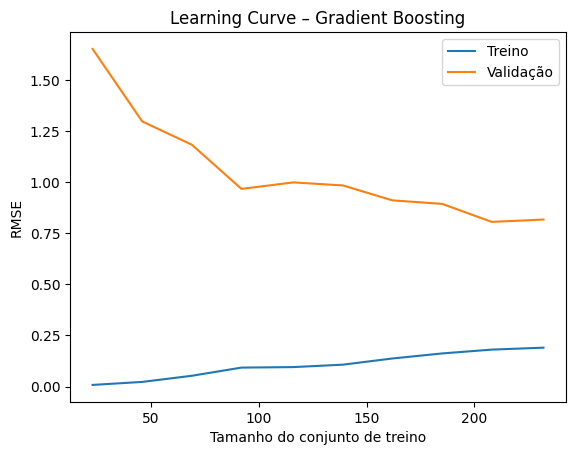

In [ ]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    model,
    X_imputed,
    y,
    cv=5,
    scoring="neg_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_rmse = np.sqrt(-train_scores.mean(axis=1))
val_rmse = np.sqrt(-val_scores.mean(axis=1))

plt.figure()
plt.plot(train_sizes, train_rmse, label="Treino")
plt.plot(train_sizes, val_rmse, label="Validação")
plt.xlabel("Tamanho do conjunto de treino")
plt.ylabel("RMSE")
plt.title("Learning Curve – Gradient Boosting")
plt.legend()
plt.show()


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score





In [ ]:
df_raw = pd.read_excel(file_path, header=None)

In [ ]:
header_row = df_raw[
    df_raw.apply(
        lambda x: x.astype(str).str.contains("fck", case=False, na=False)
    ).any(axis=1)
].index[0]

header_row

np.int64(5)

In [ ]:
df_raw = pd.read_excel(file_path, header=None)



In [ ]:
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]


In [ ]:
print(df.shape)
print(df.columns)
df.head()


(291, 9)
Index(['Tipo do concreto', 'fck (resistência)            [MPa]',
       'l (comprimento)            [mm]', 'd (diâmetro            [mm]',
       'l/d      (fator de forma', 'Teor de fibra (%)', 'N (ganchos)',
       'fR,1 (N/mm²)      (experimental)', 'fR,3 (N/mm²)      (experimental)'],
      dtype='object')


,Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)"
0,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.99000,3.32000
1,AM-0.8-EH1,63.80000,35,0.54997,63.64000,0.80000,1.00000,7.44000,5.68000
2,AM-0.4-EH2,63.60000,60,0.89996,66.67000,0.40000,1.00000,5.35000,5.53000
3,AM-0.8-EH2,58.70000,60,0.89996,66.67000,0.80000,1.00000,7.94000,8.78000
4,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.49000,3.03000


In [ ]:
X = df[[
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma',
    'Teor de fibra (%)',
    'N (ganchos)'
]]

y_fR1 = df['fR,1 (N/mm²)      (experimental)']
y_fR3 = df['fR,3 (N/mm²)      (experimental)']

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingRegressor(random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y_fR1, test_size=0.2, random_state=42
)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2:.4f}")


MAE  = 0.6701
RMSE = 0.9979
R²   = 0.8536


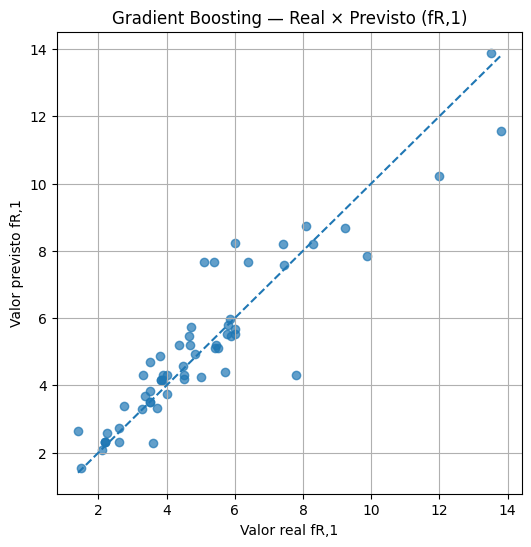

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--")
plt.xlabel("Valor real fR,1")
plt.ylabel("Valor previsto fR,1")
plt.title("Gradient Boosting — Real × Previsto (fR,1)")
plt.grid(True)
plt.show()


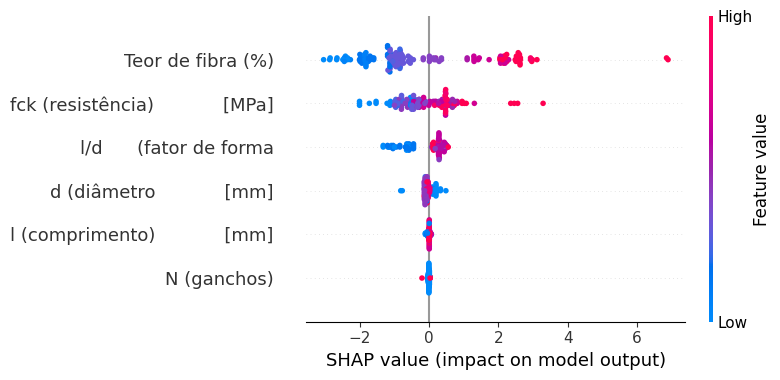

In [ ]:
import shap
import pandas as pd

# Transformar X com imputação
X_imputed = pipeline.named_steps["imputer"].transform(X)
X_imputed_df = pd.DataFrame(X_imputed, columns=X.columns)

# Subamostra segura
X_shap = X_imputed_df.sample(150, random_state=42)

explainer = shap.TreeExplainer(
    pipeline.named_steps["model"],
    feature_perturbation="interventional"
)

shap_values = explainer.shap_values(
    X_shap, check_additivity=False
)

shap.summary_plot(shap_values, X_shap)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# 1. CARREGAR OS DADOS
df_temp = pd.read_excel(file_path, header=None)
header_row = df_temp[df_temp.apply(lambda x: x.astype(str).str.contains("Tipo do concreto", case=False, na=False)).any(axis=1)].index[0]
df = pd.read_excel(file_path, header=header_row)
df = df.dropna(axis=1, how="all")

In [ ]:
# 2. DEFINIR FEATURES E TARGET
feature_cols = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]
target_col = 'fR,1 (N/mm²)      (experimental)'

X = df[feature_cols]
y = df[target_col]

# 3. DIVIDIR TREINO/TESTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. NORMALIZAR DADOS PARA TREINAMENTO DNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
X = df[
    [
        'fck (resistência)            [MPa]',
        'l (comprimento)            [mm]',
        'd (diâmetro            [mm]',
        'l/d      (fator de forma             ',
        'Teor de fibra (%)',
        'N (ganchos)'
    ]
]

y = df['fR,3 (N/mm²)      (experimental)']


In [ ]:
numeric_features = X.columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ]
)

pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)


In [ ]:
pipeline.fit(X, y)

y_pred = pipeline.predict(X)

print(y_pred[:10])


[4.15020845 7.00924334 5.29448252 7.754382   4.15020845 4.15020845
 4.15020845 4.15020845 4.15020845 4.15020845]


In [ ]:
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"MAE  = {mean_absolute_error(y, y_pred):.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2_score(y, y_pred):.4f}")


MAE  = 1.2051
RMSE = 1.5640
R²   = 0.6863


In [ ]:
# Criar DataFrame de erros
errors = np.abs(y.values - y_pred)

df_errors = X.copy()
df_errors['y_real'] = y.values
df_errors['y_pred'] = y_pred
df_errors['erro_abs'] = errors

# Definir limite das 30% piores amostras
threshold = np.quantile(df_errors['erro_abs'], 0.70)

# Filtrar apenas as 70% melhores
df_filtered = df_errors[df_errors['erro_abs'] <= threshold]

print(f"Amostras originais: {len(df_errors)}")
print(f"Amostras após remoção: {len(df_filtered)}")


Amostras originais: 291
Amostras após remoção: 204


In [ ]:
X_clean = df_filtered[X.columns]
y_clean = df_filtered['y_real']


In [ ]:
#Treinnando e avaliou o modelo já SEM os 30% piores pontos

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

pipeline.fit(X_train, y_train)

y_pred_test = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"MAE  = {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2_score(y_test, y_pred_test):.4f}")


MAE  = 0.5482
RMSE = 0.6835
R²   = 0.9254


In [ ]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# R²
r2_scores = cross_val_score(
    pipeline,
    X_clean,
    y_clean,
    cv=kf,
    scoring='r2'
)

# MAE
mae_scores = -cross_val_score(
    pipeline,
    X_clean,
    y_clean,
    cv=kf,
    scoring='neg_mean_absolute_error'
)

print("Cross-validation (5-fold):")
print(f"R² médio  = {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")
print(f"MAE médio = {mae_scores.mean():.4f}")


Cross-validation (5-fold):
R² médio  = 0.8933 ± 0.0279
MAE médio = 0.6226


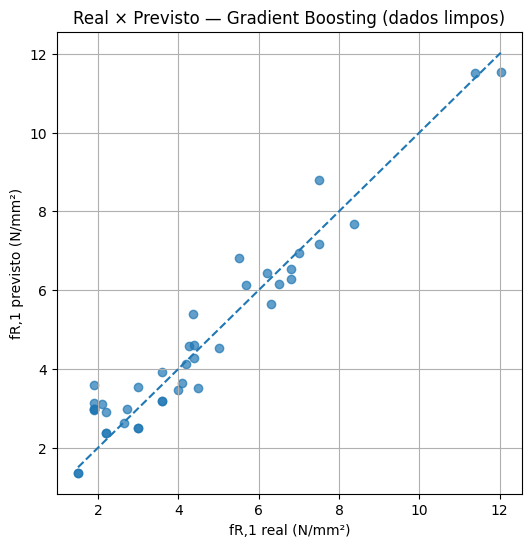

In [ ]:
import matplotlib.pyplot as plt

pipeline.fit(X_train, y_train)
y_pred_test = pipeline.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')
plt.xlabel("fR,1 real (N/mm²)")
plt.ylabel("fR,1 previsto (N/mm²)")
plt.title("Real × Previsto — Gradient Boosting (dados limpos)")
plt.grid(True)
plt.show()


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])


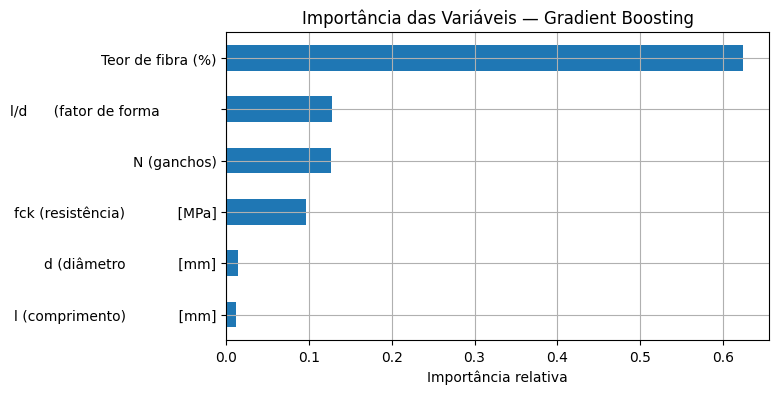

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

pipeline.fit(X_clean, y_clean)

gbr = pipeline.named_steps['model']

feature_importance = pd.Series(
    gbr.feature_importances_,
    index=X_clean.columns
).sort_values(ascending=False)

feature_importance.plot(kind='barh', figsize=(7,4))
plt.title("Importância das Variáveis — Gradient Boosting")
plt.xlabel("Importância relativa")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()


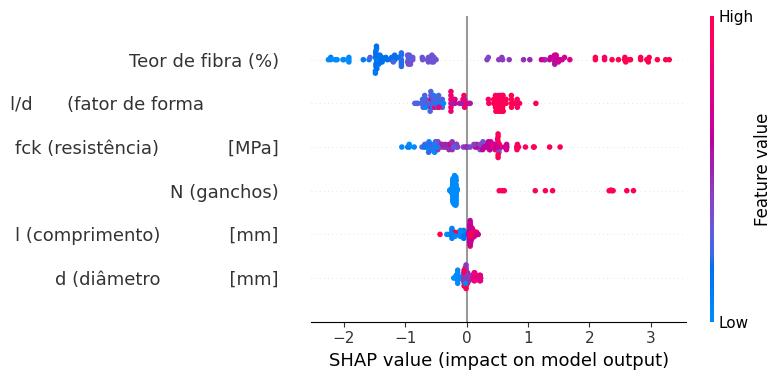

In [ ]:
import shap
import numpy as np

# Extrair o modelo treinado
gbr = pipeline.named_steps['model']

# Subconjunto pequeno (evita crash)
X_shap = X_clean.sample(
    min(120, len(X_clean)),
    random_state=42
)

# Criar o explicador (compatível com versões antigas)
explainer = shap.TreeExplainer(
    gbr,
    feature_perturbation="tree_path_dependent"
)

# Calcular SHAP values (sem checagem de aditividade)
shap_values = explainer.shap_values(X_shap)

# Gráfico resumo
shap.summary_plot(shap_values, X_shap)


In [ ]:
# Features (iguais ao fR,1)
X = df[[
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]]

# Target fR,3 <----- Olha o fr,3
y = df['fR,3 (N/mm²)      (experimental)']


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE  = {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2_score(y_test, y_pred):.4f}")


MAE  = 0.8346
RMSE = 1.1732
R²   = 0.8067


In [ ]:
#Removendo os 30% piores
#_________________________#
pipeline.fit(X, y)
y_pred_all = pipeline.predict(X)

# Erro absoluto
erro = np.abs(y - y_pred_all)

# Limite dos 30% piores
limite = np.percentile(erro, 70)

mask = erro <= limite

X_clean = X[mask]
y_clean = y[mask]

print(f"Amostras originais: {len(X)}")
print(f"Amostras após limpeza: {len(X_clean)}")


Amostras originais: 291
Amostras após limpeza: 204


In [ ]:
#TREINO FINAL DE Fr3

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

pipeline.fit(X_train, y_train)

y_pred_test = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"MAE  = {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2_score(y_test, y_pred_test):.4f}")


MAE  = 0.5652
RMSE = 1.0016
R²   = 0.9020


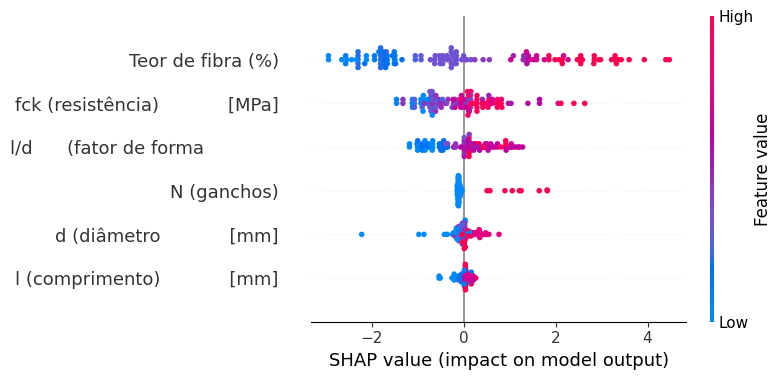

In [ ]:
#shap do fr3

import shap

gbr = pipeline.named_steps["model"]

X_shap = X_clean.sample(
    min(120, len(X_clean)),
    random_state=42
)

explainer = shap.TreeExplainer(
    gbr,
    feature_perturbation="tree_path_dependent"
)

shap_values = explainer.shap_values(X_shap)

shap.summary_plot(shap_values, X_shap)


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def train_with_outlier_removal(
    X,
    y,
    pipeline,
    remove_pct=0.2,
    test_size=0.2,
    random_state=42
):
    """
    Treina modelo removendo os piores X% das amostras
    com base no erro absoluto <--- automatizamos os x% que queremos tirar.
    """

    #  Treino inicial
    pipeline.fit(X, y)
    y_pred_all = pipeline.predict(X)

    #  Erro absoluto
    erro = np.abs(y - y_pred_all)

    #  Limite de remoção
    limite = np.percentile(erro, 100 * (1 - remove_pct))

    mask = erro <= limite

    X_clean = X[mask]
    y_clean = y[mask]

    #  Split final
    X_train, X_test, y_train, y_test = train_test_split(
        X_clean, y_clean,
        test_size=test_size,
        random_state=random_state
    )

    #  Treino final
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    #  Métricas
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "n_original": len(X),
        "n_final": len(X_clean),
        "removed_%": remove_pct * 100
    }


In [ ]:
result_fr1 = train_with_outlier_removal(
    X,
    y_fR1,
    pipeline,
    remove_pct=0.20
)

result_fr1


{'MAE': 0.4831992180162154,
 'RMSE': np.float64(0.7024643588937785),
 'R2': 0.8869184577329065,
 'n_original': 291,
 'n_final': 233,
 'removed_%': 20.0}

In [ ]:
result_fr3 = train_with_outlier_removal(
    X,
    y_fR3,
    pipeline,
    remove_pct=0.20
)

result_fr3


{'MAE': 0.5895874320319213,
 'RMSE': np.float64(0.7574278757548173),
 'R2': 0.9046048152228299,
 'n_original': 291,
 'n_final': 233,
 'removed_%': 20.0}

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# 1. CARREGAR OS DADOS
df_temp = pd.read_excel(file_path, header=None)
header_row = df_temp[df_temp.apply(lambda x: x.astype(str).str.contains("Tipo do concreto", case=False, na=False)).any(axis=1)].index[0]
df = pd.read_excel(file_path, header=header_row)
df = df.dropna(axis=1, how="all")

In [ ]:
# Variáveis de entrada
X = df[[
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]]

# Variável alvo (fR,3 por exemplo)
y = df['fR,3 (N/mm²)      (experimental)']


In [ ]:
X = df[
    [
        'fck (resistência)            [MPa]',
        'l (comprimento)            [mm]',
        'd (diâmetro            [mm]',
        'l/d      (fator de forma             ',
        'Teor de fibra (%)',
        'N (ganchos)'
    ]
]

y_fr3 = df['fR,3 (N/mm²)      (experimental)']


In [ ]:
# Treinar modelo BASE (para calcular erros)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor

pipeline_base = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

pipeline_base.fit(X, y)

y_pred_base = pipeline_base.predict(X)

In [ ]:
# célula para remover os 30%

import numpy as np

# Erro absoluto
errors = np.abs(y - y_pred_base)

# Percentil de corte (30%)
threshold = np.percentile(errors, 70)

# Máscara dos melhores dados
mask = errors <= threshold

# Dados limpos
X_clean = X.loc[mask]
y_clean = y.loc[mask]

print("Shape original:", X.shape)
print("Shape após remoção:", X_clean.shape)

Shape original: (291, 6)
Shape após remoção: (204, 6)


In [ ]:
# Treinamento (sem os 30%)
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean,
    test_size=0.2,
    random_state=42
)

pipeline_gbr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

pipeline_gbr.fit(X_train, y_train)

y_pred_test = pipeline_gbr.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"MAE  = {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2_score(y_test, y_pred_test):.4f}")

MAE  = 0.5675
RMSE = 1.0044
R²   = 0.9015


In [ ]:
data = pd.concat([X, y_fr3], axis=1).dropna()

X_clean = data[X.columns]
y_clean_fr3 = data[y_fr3.name]


In [ ]:
from sklearn.model_selection import train_test_split

X_train_clean, X_test_clean, y_train_fr3, y_test_fr3 = train_test_split(
    X_clean, y_clean_fr3,
    test_size=0.2,
    random_state=42
)


In [ ]:
# treinar gradientbooster
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor

pipeline_gbr_fr3 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

pipeline_gbr_fr3.fit(X_train_clean, y_train_fr3)


Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.05, n_estimators=300,
                                           random_state=42))])

In [ ]:
# Previsões do Gradient Boosting (baseline)
y_pred_gbr = pipeline_gbr.predict(X_clean)

In [ ]:
# Treinar a regressão linear aproximadora
from sklearn.linear_model import LinearRegression

lin_reg_eq_fr3 = LinearRegression()
lin_reg_eq_fr3.fit(X_clean, y_pred_gbr)

LinearRegression()

In [ ]:
#cria equação para fr3
from sklearn.linear_model import LinearRegression

# Previsões do GBR
y_pred_gbr_fr3 = pipeline_gbr_fr3.predict(X_clean)

# Ajustar equação linear
lin_reg_eq_fr3 = LinearRegression()
lin_reg_eq_fr3.fit(X_clean, y_pred_gbr_fr3)


LinearRegression()

In [ ]:
# Extrair a equação matemática -> Equação fr3
import pandas as pd

coef_eq_fr3 = pd.Series(
    lin_reg_eq_fr3.coef_,
    index=X_clean.columns
)

intercept_eq_fr3 = lin_reg_eq_fr3.intercept_

coef_eq_fr3, intercept_eq_fr3

(fck (resistência)            [MPa]       0.05081
 l (comprimento)            [mm]          0.05436
 d (diâmetro            [mm]             -1.26323
 l/d      (fator de forma                 0.00326
 Teor de fibra (%)                        6.94314
 N (ganchos)                              2.42193
 dtype: float64,
 np.float64(-5.588618129622345))

In [ ]:
# First, make sure you've trained your model
# For example, if you're using LinearRegression:
from sklearn.linear_model import LinearRegression

# Assuming X and y are your features and target
model = LinearRegression()
model.fit(X, y)

# Now get the coefficients
intercept = model.intercept_
coefficients = model.coef_

# Create the equation string
equation = f"ŷ = {intercept:.4f}"

for i, coef in enumerate(coefficients):
    feature_name = X.columns[i]  # Get the feature name
    equation += f" + ({coef:.4f} × {feature_name})"

print("Regression Equation:")
print(equation)

Regression Equation:
ŷ = -5.2886 + (0.0539 × fck (resistência)            [MPa]) + (0.0708 × l (comprimento)            [mm]) + (-2.0902 × d (diâmetro            [mm]) + (-0.0061 × l/d      (fator de forma             ) + (6.8105 × Teor de fibra (%)) + (2.4702 × N (ganchos))


In [ ]:
import pandas as pd

# Variáveis usadas nas equações
features = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]

def testar_equacoes(df, idx):
    """
    Testa as equações lineares de fR,3
    para uma linha específica do banco de dados.
    """
    X_row = df.loc[[idx], features]

    fr3_pred = lin_reg_eq_fr3.predict(X_row)[0]

    print(f"🔎 Amostra índice {idx}")
    print("-" * 40)
    print("Entradas:")
    display(X_row)

    print("\n📐 Resultados das equações:")
    print(f"fR,3 (equação) = {fr3_pred:.3f} N/mm²")

# ====== USO ======
# Exemplo: testar a amostra de índice 10
testar_equacoes(df, idx=10)

🔎 Amostra índice 10
----------------------------------------
Entradas:


,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos)
10,61.30000,35,0.54997,63.64000,0.40000,1.00000



📐 Resultados das equações:
fR,3 (equação) = 4.141 N/mm²


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. First, make sure you have your training data ready
# X_train_clean, X_test_clean, y_train_fr3, y_test_fr3 should be defined

# 2. Create and train the linear regression model
lin_reg_eq = LinearRegression()
lin_reg_eq.fit(X_train_clean, y_train_fr3)

# 3. Now you can make predictions
y_pred_eq_fr3 = lin_reg_eq.predict(X_test_clean)

# 4. Evaluate the model
rmse_eq = np.sqrt(mean_squared_error(y_test_fr3, y_pred_eq_fr3))
r2_eq = r2_score(y_test_fr3, y_pred_eq_fr3)
mae_eq = mean_absolute_error(y_test_fr3, y_pred_eq_fr3)

print("Avaliação da EQUAÇÃO — fR,3")
print("=" * 40)
print(f"RMSE: {rmse_eq:.4f}")
print(f"R²: {r2_eq:.4f}")
print(f"MAE: {mae_eq:.4f}")

# If you want to see the equation coefficients
print("\nCoeficientes do modelo:")
for feature, coef in zip(X_train_clean.columns, lin_reg_eq.coef_):
    print(f"{feature}: {coef:.6f}")
print(f"Intercept: {lin_reg_eq.intercept_:.6f}")

Avaliação da EQUAÇÃO — fR,3
RMSE: 1.6366
R²: 0.6237
MAE: 1.2014

Coeficientes do modelo:
fck (resistência)            [MPa]: 0.052122
l (comprimento)            [mm]: 0.077063
d (diâmetro            [mm]: -2.596260
l/d      (fator de forma             : -0.015048
Teor de fibra (%): 7.076643
N (ganchos): 2.411489
Intercept: -4.645538


In [ ]:
# Treinar modelo BASE (para calcular erros)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor

pipeline_base = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

pipeline_base.fit(X, y)

y_pred_base = pipeline_base.predict(X)


In [ ]:
# célula para remover os 30%

import numpy as np

# Erro absoluto
errors = np.abs(y - y_pred_base)

# Percentil de corte (30%)
threshold = np.percentile(errors, 70)

# Máscara dos melhores dados
mask = errors <= threshold

# Dados limpos
X_clean = X.loc[mask]
y_clean = y.loc[mask]

print("Shape original:", X.shape)
print("Shape após remoção:", X_clean.shape)

Shape original: (291, 6)
Shape após remoção: (207, 6)


In [ ]:
# Treinamento (sem os 30%)
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean,
    test_size=0.2,
    random_state=42
)

pipeline_gbr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

pipeline_gbr.fit(X_train, y_train)

y_pred_test = pipeline_gbr.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"MAE  = {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2_score(y_test, y_pred_test):.4f}")


MAE  = 0.6396
RMSE = 1.1588
R²   = 0.8075


In [ ]:
# GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean,
    test_size=0.2,
    random_state=42
)

pipeline_gbr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

pipeline_gbr.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.05, n_estimators=300,
                                           random_state=42))])

In [ ]:
# Previsões do Gradient Boosting (baseline)
y_pred_gbr = pipeline_gbr.predict(X_clean)


In [ ]:
# Extrair a equação matemática -> Equação fr3
import pandas as pd

coef_eq = pd.Series(
    lin_reg_eq.coef_,
    index=X_clean.columns
)

intercept_eq = lin_reg_eq.intercept_

coef_eq, intercept_eq


(fck (resistência)            [MPa]       0.05212
 l (comprimento)            [mm]          0.07706
 d (diâmetro            [mm]             -2.59626
 l/d      (fator de forma                -0.01505
 Teor de fibra (%)                        7.07664
 N (ganchos)                              2.41149
 dtype: float64,
 np.float64(-4.645538110552916))

In [ ]:
# Mostrar a equação formatada (bonita) -> Equação fr3
equation = "ŷ = " + f"{intercept_eq:.4f}"

for var, coef in coef_eq.items():
    equation += f" + ({coef:.4f} × {var})"

print(equation)


ŷ = -4.6455 + (0.0521 × fck (resistência)            [MPa]) + (0.0771 × l (comprimento)            [mm]) + (-2.5963 × d (diâmetro            [mm]) + (-0.0150 × l/d      (fator de forma             ) + (7.0766 × Teor de fibra (%)) + (2.4115 × N (ganchos))


In [ ]:
# Validar o quão boa é a equação aproximada -> Analise da Equação fr3
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_hat_eq = lin_reg_eq.predict(X_clean)

print(f"MAE  = {mean_absolute_error(y_pred_gbr, y_hat_eq):.4f}")
print(f"RMSE = {np.sqrt(mean_squared_error(y_pred_gbr, y_hat_eq)):.4f}")
print(f"R²   = {r2_score(y_pred_gbr, y_hat_eq):.4f}")


MAE  = 0.7537
RMSE = 1.0450
R²   = 0.8086


In [ ]:
# Agora fazer o processo para fr1 pra obter a equação fr1
import pandas as pd

# Conferir colunas
df.columns


Index(['Tipo do concreto', 'fck (resistência)            [MPa]',
       'l (comprimento)            [mm]', 'd (diâmetro            [mm]',
       'l/d      (fator de forma             ', 'Teor de fibra (%)',
       'N (ganchos)', 'fR,1 (N/mm²)      (experimental)',
       'fR,3 (N/mm²)      (experimental)', 'Unnamed: 13', 'Unnamed: 14',
       'Unnamed: 15'],
      dtype='object')

In [ ]:
# Variáveis de entrada
X = df[
    [
        'fck (resistência)            [MPa]',
        'l (comprimento)            [mm]',
        'd (diâmetro            [mm]',
        'l/d      (fator de forma             ',
        'Teor de fibra (%)',
        'N (ganchos)'
    ]
]

# Variável alvo → fR,1
y = df['fR,1 (N/mm²)      (experimental)']

print(X.shape, y.shape)


(291, 6) (291,)


In [ ]:
# Remover NaNs
data = pd.concat([X, y], axis=1).dropna()

X = data[X.columns]
y = data[y.name]

print("Após limpeza:", X.shape)


Após limpeza: (291, 6)


In [ ]:
# Treinar Gradient Boosting
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline_gbr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

pipeline_gbr.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.05, n_estimators=300,
                                           random_state=42))])

In [ ]:
# Avaliação (confirma se é fR,1)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = pipeline_gbr.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE  = {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2_score(y_test, y_pred):.4f}")


MAE  = 0.6434
RMSE = 0.9826
R²   = 0.8581


In [ ]:
# Prever com o pipeline_gbr no conjunto X completo para obter y_gbr
y_gbr = pipeline_gbr.predict(X)

# Fit the linear model
lin_eq_fr1 = LinearRegression()
lin_eq_fr1.fit(X, y_gbr)

# Get coefficients - use the same variable name you used to fit the model
coef = pd.Series(lin_eq_fr1.coef_, index=X.columns)  # Changed lin_eq to lin_eq_fr1
intercept = lin_eq_fr1.intercept_

# Display results
print("Coefficients:")
print(coef)
print(f"\nIntercept: {intercept}")

# If you want to see the equation
equation = f"y = {intercept:.4f}"
for name, value in coef.items():
    equation += f" + ({value:.4f} × {name})"

print("\nRegression Equation:")
print(equation)

Coefficients:
fck (resistência)            [MPa]       0.06456
l (comprimento)            [mm]         -0.01673
d (diâmetro            [mm]              0.88075
l/d      (fator de forma                 0.04612
Teor de fibra (%)                        6.64834
N (ganchos)                              0.49745
dtype: float64

Intercept: -4.8584591152149095

Regression Equation:
y = -4.8585 + (0.0646 × fck (resistência)            [MPa]) + (-0.0167 × l (comprimento)            [mm]) + (0.8808 × d (diâmetro            [mm]) + (0.0461 × l/d      (fator de forma             ) + (6.6483 × Teor de fibra (%)) + (0.4975 × N (ganchos))


In [ ]:
# Mostrar a EQUAÇÃO DO fR,1 mais formatada
equation = f"ŷ = {intercept:.4f}"

for feature, value in coef.items():
    equation += f" + ({value:.4f} × {feature})"

print("Equação aproximada para fR,1:\n")
print(equation)


Equação aproximada para fR,1:

ŷ = -4.8585 + (0.0646 × fck (resistência)            [MPa]) + (-0.0167 × l (comprimento)            [mm]) + (0.8808 × d (diâmetro            [mm]) + (0.0461 × l/d      (fator de forma             ) + (6.6483 × Teor de fibra (%)) + (0.4975 × N (ganchos))


In [ ]:
# First, make sure you have your model trained
# If you followed the previous example, you should have this:
# lin_eq_fr1 = LinearRegression()
# lin_eq_fr1.fit(X_train, y_train)  # Make sure to use your training data

# Then make predictions using the correct model name
y_pred_eq = lin_eq_fr1.predict(X_test)  # Changed from lin_eq to lin_eq_fr1

# Calculate metrics
rmse_eq = np.sqrt(mean_squared_error(y_test, y_pred_eq))
r2_eq = r2_score(y_test, y_pred_eq)
mae_eq = mean_absolute_error(y_test, y_pred_eq)

# Print evaluation metrics
print("Avaliação da EQUAÇÃO fR,1")
print("=" * 40)
print(f"RMSE: {rmse_eq:.4f}")
print(f"R²: {r2_eq:.4f}")
print(f"MAE: {mae_eq:.4f}")

# If you want to see actual vs predicted values
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_eq,
    'Difference': y_test - y_pred_eq
})
print("\nPrimeiras 10 previsões:")
print(results.head(10))

Avaliação da EQUAÇÃO fR,1
RMSE: 1.3635
R²: 0.7267
MAE: 1.0027

Primeiras 10 previsões:
      Actual  Predicted  Difference
84  13.50000   16.48366    -2.98366
259  9.87000    6.80755     3.06245
45   5.99040    6.68448    -0.69408
176  4.70000    4.92149    -0.22149
143  2.60000    1.76190     0.83810
125  4.00000    4.47471    -0.47471
226  7.40000    7.47199    -0.07199
118  2.20000    2.46190    -0.26190
9    5.46000    5.08949     0.37051
90   1.50000    1.22636     0.27364


In [ ]:
import pandas as pd

# Variáveis usadas nas equações
features = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]

def testar_equacoes(df, idx):
    """
    Testa as equações lineares de fR,1
    para uma linha específica do banco de dados.
    """
    X_row = df.loc[[idx], features]

    fr1_pred = lin_eq_fr1.predict(X_row)[0]

    print(f"🔎 Amostra índice {idx}")
    print("-" * 40)
    print("Entradas:")
    display(X_row)

    print("\n📐 Resultados das equações:")
    print(f"fR,1 (equação) = {fr1_pred:.3f} N/mm²")


# ====== USO ======
# Exemplo: testar a amostra de índice 10
testar_equacoes(df, idx=10)


🔎 Amostra índice 10
----------------------------------------
Entradas:


,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos)
10,61.30000,35,0.54997,63.64000,0.40000,1.00000



📐 Resultados das equações:
fR,1 (equação) = 5.089 N/mm²


In [ ]:
import pandas as pd

# Variáveis de entrada (EXATAMENTE as usadas no treino)
features = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]

def testar_equacoes_lote(df, indices):
    """
    Testa as equações lineares de fR,1 e fR,3
    para múltiplas linhas do banco de dados.
    """
    X = df.loc[indices, features]

    # Previsões
    fr1_eq = lin_eq_fr1.predict(X)
    fr3_eq = lin_reg_eq_fr3.predict(X)

    # Resultados experimentais
    fr1_exp = df.loc[indices, 'fR,1 (N/mm²)      (experimental)']
    fr3_exp = df.loc[indices, 'fR,3 (N/mm²)      (experimental)']

    result = pd.DataFrame({
        "fck [MPa]": X[features[0]].values,
        "Teor de fibra (%)": X['Teor de fibra (%)'].values,
        "fR,1 exp": fr1_exp.values,
        "fR,1 eq": fr1_eq,
        "Erro fR,1": fr1_eq - fr1_exp.values,
        "fR,3 exp": fr3_exp.values,
        "fR,3 eq": fr3_eq,
        "Erro fR,3": fr3_eq - fr3_exp.values
    }, index=indices)

    return result

# ===== USO =====
# Escolha índices do banco
indices_teste = [5, 12, 25, 40, 60, 1, 7, 33, 27, 24]

df_resultados = testar_equacoes_lote(df, indices_teste)
df_resultados


,fck [MPa],Teor de fibra (%),"fR,1 exp","fR,1 eq","Erro fR,1","fR,3 exp","fR,3 eq","Erro fR,3"
5,61.30000,0.40000,4.37000,5.08949,0.71949,3.28000,4.14095,0.86095
12,22.00000,0.50000,4.12800,3.29408,-0.83392,4.70400,3.41674,-1.28726
25,24.00000,0.50000,3.37920,3.21196,-0.16724,3.40800,2.81930,-0.58870
40,22.00000,0.50000,2.63040,2.52107,-0.10933,2.74560,2.41284,-0.33276
60,59.00000,0.50000,3.79000,6.11821,2.32821,4.55000,5.87813,1.32813
1,63.80000,0.80000,7.44000,7.91022,0.47022,5.68000,7.04523,1.36523
7,61.30000,0.40000,5.22000,5.08949,-0.13051,3.06000,4.14095,1.08095
33,43.00000,0.50000,5.86560,4.43854,-1.42706,6.60480,3.78475,-2.82005
27,24.00000,1.00000,5.71200,6.53614,0.82414,5.12640,6.29087,1.16447
24,24.00000,0.50000,2.75520,3.21196,0.45676,2.64000,2.81930,0.17930


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

# Entradas
X = df[[
    'fck (resistência)            [MPa]',
    'Teor de fibra (%)'
]]

y_fr1 = df['fR,1 (N/mm²)      (experimental)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_fr1, test_size=0.2, random_state=42
)

pipeline_gbr_fr1 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        random_state=42
    ))
])

pipeline_gbr_fr1.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.05, n_estimators=300,
                                           random_state=42))])

In [ ]:
y_fr3 = df['fR,3 (N/mm²)      (experimental)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_fr3, test_size=0.2, random_state=42
)

pipeline_gbr_fr3 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        random_state=42
    ))
])

pipeline_gbr_fr3.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.05, n_estimators=300,
                                           random_state=42))])

In [ ]:
import pandas as pd

X_all = df[[
    'fck (resistência)            [MPa]',
    'Teor de fibra (%)'
]]

fr1_exp = df['fR,1 (N/mm²)      (experimental)']
fr3_exp = df['fR,3 (N/mm²)      (experimental)']

fr1_gbr = pipeline_gbr_fr1.predict(X_all)
fr3_gbr = pipeline_gbr_fr3.predict(X_all)

import pandas as pd



tabela_gbr = pd.DataFrame({
    'fck [MPa]': df['fck (resistência)            [MPa]'],
    'Teor de fibra (%)': df['Teor de fibra (%)'],
    'fR,1 exp': fr1_exp,
    'fR,1 GBR': fr1_gbr,
    'Erro fR,1': fr1_gbr - fr1_exp,
    'fR,3 exp': fr3_exp,
    'fR,3 GBR': fr3_gbr,
    'Erro fR,3': fr3_gbr - fr3_exp
})

import pandas as pd

pd.set_option('display.max_rows', 300)
pd.set_option('display.max_columns', None)

tabela_gbr


,fck [MPa],Teor de fibra (%),"fR,1 exp","fR,1 GBR","Erro fR,1","fR,3 exp","fR,3 GBR","Erro fR,3"
0,61.30000,0.40000,4.99000,4.96060,-0.02940,3.32000,3.52767,0.20767
1,63.80000,0.80000,7.44000,7.46216,0.02216,5.68000,6.11738,0.43738
2,63.60000,0.40000,5.35000,5.21523,-0.13477,5.53000,4.44259,-1.08741
3,58.70000,0.80000,7.94000,8.08801,0.14801,8.78000,8.26406,-0.51594
4,61.30000,0.40000,5.49000,4.96060,-0.52940,3.03000,3.52767,0.49767
5,61.30000,0.40000,4.37000,4.96060,0.59060,3.28000,3.52767,0.24767
6,61.30000,0.40000,4.67000,4.96060,0.29060,2.98000,3.52767,0.54767
7,61.30000,0.40000,5.22000,4.96060,-0.25940,3.06000,3.52767,0.46767
8,61.30000,0.40000,4.74000,4.96060,0.22060,3.50000,3.52767,0.02767
9,61.30000,0.40000,5.46000,4.96060,-0.49940,4.09000,3.52767,-0.56233


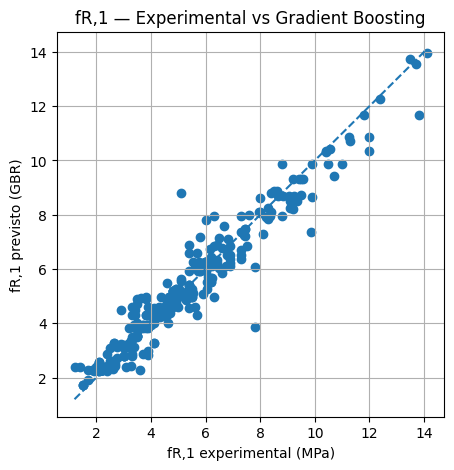

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.scatter(tabela_gbr['fR,1 exp'], tabela_gbr['fR,1 GBR'])
plt.plot(
    [tabela_gbr['fR,1 exp'].min(), tabela_gbr['fR,1 exp'].max()],
    [tabela_gbr['fR,1 exp'].min(), tabela_gbr['fR,1 exp'].max()],
    '--'
)
plt.xlabel('fR,1 experimental (MPa)')
plt.ylabel('fR,1 previsto (GBR)')
plt.title('fR,1 — Experimental vs Gradient Boosting')
plt.grid(True)
plt.show()


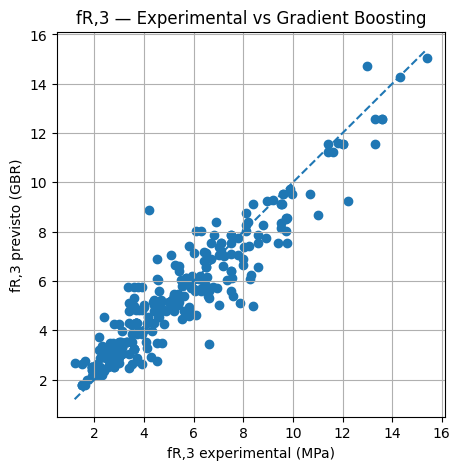

In [ ]:
plt.figure(figsize=(5,5))
plt.scatter(tabela_gbr['fR,3 exp'], tabela_gbr['fR,3 GBR'])
plt.plot(
    [tabela_gbr['fR,3 exp'].min(), tabela_gbr['fR,3 exp'].max()],
    [tabela_gbr['fR,3 exp'].min(), tabela_gbr['fR,3 exp'].max()],
    '--'
)
plt.xlabel('fR,3 experimental (MPa)')
plt.ylabel('fR,3 previsto (GBR)')
plt.title('fR,3 — Experimental vs Gradient Boosting')
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("GBR — fR,1")
print("MAE :", mean_absolute_error(tabela_gbr['fR,1 exp'], tabela_gbr['fR,1 GBR']))
print("RMSE:", np.sqrt(mean_squared_error(tabela_gbr['fR,1 exp'], tabela_gbr['fR,1 GBR'])))
print("R²  :", r2_score(tabela_gbr['fR,1 exp'], tabela_gbr['fR,1 GBR']))

print("\nGBR — fR,3")
print("MAE :", mean_absolute_error(tabela_gbr['fR,3 exp'], tabela_gbr['fR,3 GBR']))
print("RMSE:", np.sqrt(mean_squared_error(tabela_gbr['fR,3 exp'], tabela_gbr['fR,3 GBR'])))
print("R²  :", r2_score(tabela_gbr['fR,3 exp'], tabela_gbr['fR,3 GBR']))


GBR — fR,1
MAE : 0.4525712186611504
RMSE: 0.672657053867307
R²  : 0.930070396305028

GBR — fR,3
MAE : 0.7064883751650248
RMSE: 0.9802834108000597
R²  : 0.8767823256435324


In [ ]:
# Remoção de 30% usando Linear Regression
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

remove_pct = 0.30

# Treinar modelo
lin_reg = LinearRegression()
lin_reg.fit(X, y)

# Previsões
y_pred = lin_reg.predict(X)

# Erro absoluto
errors = np.abs(y - y_pred)

# Quantidade a remover
n_remove = int(len(errors) * remove_pct)

# Índices removidos
removed_idx_lr = errors.sort_values(ascending=False).head(n_remove).index

# Dataset limpo
X_clean_lr = X.drop(index=removed_idx_lr)
y_clean_lr = y.drop(index=removed_idx_lr)

print("Linear Regression")
print(f"Amostras removidas: {n_remove}")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

display(df.loc[removed_idx_lr])



Linear Regression
Amostras removidas: 87


,Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)",Unnamed: 13,Unnamed: 14,Unnamed: 15
79,BEN - 1,66.20000,50,0.62500,80.00000,1.00000,1.00000,13.80000,11.60000,10.31362,0.25264,erro alto
88,"CUE - 0,65",61.10000,30,0.62500,48.00000,0.64583,1.00000,2.90000,2.80000,6.16248,1.12499,erro alto
71,"LEE - 1,00",49.80000,60,0.92308,65.00000,1.00000,1.00000,12.00000,13.30000,8.45272,0.29561,erro alto
63,"3D-1,0",51.00000,60,0.90000,66.66667,1.00000,1.00000,12.00000,13.31000,8.61615,0.28199,erro alto
218,"TIB - 1,00",25.10000,35,0.54688,64.00000,1.00000,1.00000,9.90000,7.20000,6.09986,0.38385,erro alto
259,B403 - 27,67.70000,30,0.37999,78.95000,0.50000,1.00000,9.87000,8.90000,6.28595,0.36313,erro alto
201,"TIB - 0,76",60.90000,50,0.89286,56.00000,0.76000,1.00000,10.70000,9.50000,7.26679,0.32086,erro alto
66,"ABD - 1,0",46.80000,35,0.53846,65.00000,1.00000,1.00000,5.10000,4.20000,8.20997,0.60980,erro alto
160,"MON - 1,00",63.20000,60,0.75000,80.00000,1.00000,1.00000,6.50000,5.80000,10.09172,0.55257,erro alto
253,"4D-1,0",51.00000,60,0.90000,66.66667,1.00000,1.50000,11.26000,13.57000,8.94738,0.20538,erro alto


In [ ]:
#Remoção de 30% usando Random Forest
from sklearn.ensemble import RandomForestRegressor

remove_pct = 0.30

# Treinar modelo
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)
rf.fit(X, y)

# Previsões
y_pred = rf.predict(X)

# Erro absoluto
errors = np.abs(y - y_pred)

# Quantidade a remover
n_remove = int(len(errors) * remove_pct)

# Índices removidos
removed_idx_rf = errors.sort_values(ascending=False).head(n_remove).index

# Dataset limpo
X_clean_rf = X.drop(index=removed_idx_rf)
y_clean_rf = y.drop(index=removed_idx_rf)

print("Random Forest")
print(f"Amostras removidas: {n_remove}")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

display(df.loc[removed_idx_rf])


Random Forest
Amostras removidas: 87


,Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)",Unnamed: 13,Unnamed: 14,Unnamed: 15
230,"TIB - 0,50",50.40000,60,0.80000,75.00000,0.50000,1.00000,7.80000,8.40000,5.38563,0.30954,erro alto
218,"TIB - 1,00",25.10000,35,0.54688,64.00000,1.00000,1.00000,9.90000,7.20000,6.09986,0.38385,erro alto
259,B403 - 27,67.70000,30,0.37999,78.95000,0.50000,1.00000,9.87000,8.90000,6.28595,0.36313,erro alto
198,"TIB - 0,76",60.00000,37,0.74000,50.00000,0.76000,1.00000,6.30000,6.10000,6.96292,0.10523,False
67,"ABD - 0,5",48.50000,60,0.92308,65.00000,0.50000,1.00000,5.60000,4.60000,5.05608,0.09713,False
260,B406 - 27,89.50000,30,0.37999,78.95000,0.50000,1.00000,10.57000,8.12000,7.16522,0.32212,erro alto
192,"TIB - 0,76",60.00000,50,0.74627,67.00000,0.76000,1.00000,8.80000,9.70000,7.63603,0.13227,False
160,"MON - 1,00",63.20000,60,0.75000,80.00000,1.00000,1.00000,6.50000,5.80000,10.09172,0.55257,erro alto
137,"BAR - 0,93",64.50000,60,0.92308,65.00000,0.93000,1.00000,8.80000,6.70000,9.05476,0.02895,False
88,"CUE - 0,65",61.10000,30,0.62500,48.00000,0.64583,1.00000,2.90000,2.80000,6.16248,1.12499,erro alto


In [ ]:
#Remoção de 30% usando Gradient Boosting (o melhor modelo)
from sklearn.ensemble import GradientBoostingRegressor

remove_pct = 0.30

# Treinar modelo
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr.fit(X, y)

# Previsões
y_pred = gbr.predict(X)

# Erro absoluto
errors = np.abs(y - y_pred)

# Quantidade a remover
n_remove = int(len(errors) * remove_pct)

# Índices removidos
removed_idx_gbr = errors.sort_values(ascending=False).head(n_remove).index

# Dataset limpo
X_clean_gbr = X.drop(index=removed_idx_gbr)
y_clean_gbr = y.drop(index=removed_idx_gbr)

print("Gradient Boosting")
print(f"Amostras removidas: {n_remove}")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

display(df.loc[removed_idx_gbr])


Gradient Boosting
Amostras removidas: 87


,Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)",Unnamed: 13,Unnamed: 14,Unnamed: 15
66,"ABD - 1,0",46.80000,35,0.53846,65.00000,1.00000,1.00000,5.10000,4.20000,8.20997,0.60980,erro alto
71,"LEE - 1,00",49.80000,60,0.92308,65.00000,1.00000,1.00000,12.00000,13.30000,8.45272,0.29561,erro alto
198,"TIB - 0,76",60.00000,37,0.74000,50.00000,0.76000,1.00000,6.30000,6.10000,6.96292,0.10523,False
203,"TIB - 0,57",57.40000,50,0.74627,67.00000,0.57000,1.00000,7.80000,9.40000,6.07367,0.22132,erro alto
230,"TIB - 0,50",50.40000,60,0.80000,75.00000,0.50000,1.00000,7.80000,8.40000,5.38563,0.30954,erro alto
220,"TIB - 1,00",37.20000,35,0.54688,64.00000,1.00000,1.00000,9.50000,8.10000,7.33597,0.22779,erro alto
201,"TIB - 0,76",60.90000,50,0.89286,56.00000,0.76000,1.00000,10.70000,9.50000,7.26679,0.32086,erro alto
188,"TIB - 0,57",40.90000,50,0.74627,67.00000,0.57000,1.00000,6.30000,6.60000,5.18107,0.17761,False
218,"TIB - 1,00",25.10000,35,0.54688,64.00000,1.00000,1.00000,9.90000,7.20000,6.09986,0.38385,erro alto
217,"TIB - 0,50",47.00000,35,0.54688,64.00000,0.50000,1.00000,6.60000,3.50000,4.95783,0.24881,erro alto


In [ ]:
#Linear Regression
#Amostras que ficaram após remover 30%

from sklearn.linear_model import LinearRegression
import numpy as np

remove_pct = 0.30

# Treinamento
lin_reg = LinearRegression()
lin_reg.fit(X, y)

# Previsões
y_pred = lin_reg.predict(X)

# Erro absoluto
errors = np.abs(y - y_pred)

# Quantidade removida
n_remove = int(len(errors) * remove_pct)

# Índices removidos
removed_idx_lr = errors.sort_values(ascending=False).head(n_remove).index

# Índices que ficaram
kept_idx_lr = X.index.difference(removed_idx_lr)

# Dataset final
X_kept_lr = X.loc[kept_idx_lr]
y_kept_lr = y.loc[kept_idx_lr]

print("Linear Regression")
print(f"Amostras originais: {len(X)}")
print(f"Amostras removidas: {len(removed_idx_lr)}")
print(f"Amostras mantidas: {len(X_kept_lr)}")

display(df.loc[kept_idx_lr])


Linear Regression
Amostras originais: 291
Amostras removidas: 87
Amostras mantidas: 204


,Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)",Unnamed: 13,Unnamed: 14,Unnamed: 15
0,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.99000,3.32000,4.76991,0.04411,False
1,AM-0.8-EH1,63.80000,35,0.54997,63.64000,0.80000,1.00000,7.44000,5.68000,8.02504,0.07863,False
2,AM-0.4-EH2,63.60000,60,0.89996,66.67000,0.40000,1.00000,5.35000,5.53000,4.92472,0.07949,False
3,AM-0.8-EH2,58.70000,60,0.89996,66.67000,0.80000,1.00000,7.94000,8.78000,7.83153,0.01366,False
4,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.49000,3.03000,4.76991,0.13116,False
5,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.37000,3.28000,4.76991,0.09151,False
6,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.67000,2.98000,4.76991,0.02139,False
7,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.22000,3.06000,4.76991,0.08622,False
8,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.74000,3.50000,4.76991,0.00631,False
9,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.46000,4.09000,4.76991,0.12639,False


In [ ]:
#Random Forest
#Amostras que ficaram após remover 30%

from sklearn.ensemble import RandomForestRegressor

remove_pct = 0.30

# Treinamento
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)
rf.fit(X, y)

# Previsões
y_pred = rf.predict(X)

# Erro absoluto
errors = np.abs(y - y_pred)

# Quantidade removida
n_remove = int(len(errors) * remove_pct)

# Índices removidos
removed_idx_rf = errors.sort_values(ascending=False).head(n_remove).index

# Índices mantidos
kept_idx_rf = X.index.difference(removed_idx_rf)

# Dataset final
X_kept_rf = X.loc[kept_idx_rf]
y_kept_rf = y.loc[kept_idx_rf]

print("Random Forest")
print(f"Amostras originais: {len(X)}")
print(f"Amostras removidas: {len(removed_idx_rf)}")
print(f"Amostras mantidas: {len(X_kept_rf)}")

display(df.loc[kept_idx_rf])


Random Forest
Amostras originais: 291
Amostras removidas: 87
Amostras mantidas: 204


,Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)",Unnamed: 13,Unnamed: 14,Unnamed: 15
0,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.99000,3.32000,4.76991,0.04411,False
1,AM-0.8-EH1,63.80000,35,0.54997,63.64000,0.80000,1.00000,7.44000,5.68000,8.02504,0.07863,False
2,AM-0.4-EH2,63.60000,60,0.89996,66.67000,0.40000,1.00000,5.35000,5.53000,4.92472,0.07949,False
3,AM-0.8-EH2,58.70000,60,0.89996,66.67000,0.80000,1.00000,7.94000,8.78000,7.83153,0.01366,False
6,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.67000,2.98000,4.76991,0.02139,False
7,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.22000,3.06000,4.76991,0.08622,False
8,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.74000,3.50000,4.76991,0.00631,False
10,AM-0.4-EH,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.93000,3.33000,4.76991,0.03247,False
11,AM-0.8-EH,63.80000,35,0.54997,63.64000,0.80000,1.00000,7.46000,5.68000,8.02504,0.07574,False
15,"1.0FF320MPA, 4",22.00000,50,0.74627,67.00000,1.00000,1.00000,5.78880,5.50080,5.81758,0.00497,False


In [ ]:
#Gradient Boosting (modelo final)
#Amostras que ficaram após remover 30%

from sklearn.ensemble import GradientBoostingRegressor

remove_pct = 0.30

# Treinamento
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr.fit(X, y)

# Previsões
y_pred = gbr.predict(X)

# Erro absoluto
errors = np.abs(y - y_pred)

# Quantidade removida
n_remove = int(len(errors) * remove_pct)

# Índices removidos
removed_idx_gbr = errors.sort_values(ascending=False).head(n_remove).index

# Índices mantidos
kept_idx_gbr = X.index.difference(removed_idx_gbr)

# Dataset final
X_kept_gbr = X.loc[kept_idx_gbr]
y_kept_gbr = y.loc[kept_idx_gbr]

print("Gradient Boosting")
print(f"Amostras originais: {len(X)}")
print(f"Amostras removidas: {len(removed_idx_gbr)}")
print(f"Amostras mantidas: {len(X_kept_gbr)}")

display(df.loc[kept_idx_gbr])


Gradient Boosting
Amostras originais: 291
Amostras removidas: 87
Amostras mantidas: 204


,Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)",Unnamed: 13,Unnamed: 14,Unnamed: 15
0,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.99000,3.32000,4.76991,0.04411,False
1,AM-0.8-EH1,63.80000,35,0.54997,63.64000,0.80000,1.00000,7.44000,5.68000,8.02504,0.07863,False
2,AM-0.4-EH2,63.60000,60,0.89996,66.67000,0.40000,1.00000,5.35000,5.53000,4.92472,0.07949,False
3,AM-0.8-EH2,58.70000,60,0.89996,66.67000,0.80000,1.00000,7.94000,8.78000,7.83153,0.01366,False
5,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.37000,3.28000,4.76991,0.09151,False
6,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.67000,2.98000,4.76991,0.02139,False
7,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.22000,3.06000,4.76991,0.08622,False
8,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.74000,3.50000,4.76991,0.00631,False
9,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.46000,4.09000,4.76991,0.12639,False
10,AM-0.4-EH,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.93000,3.33000,4.76991,0.03247,False


In [ ]:
common_kept = (
    set(kept_idx_lr)
    & set(kept_idx_rf)
    & set(kept_idx_gbr)
)

print(f"Amostras mantidas pelos 3 modelos: {len(common_kept)}")
display(df.loc[list(common_kept)])


Amostras mantidas pelos 3 modelos: 152


,Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)",Unnamed: 13,Unnamed: 14,Unnamed: 15
0,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.99000,3.32000,4.76991,0.04411,False
1,AM-0.8-EH1,63.80000,35,0.54997,63.64000,0.80000,1.00000,7.44000,5.68000,8.02504,0.07863,False
2,AM-0.4-EH2,63.60000,60,0.89996,66.67000,0.40000,1.00000,5.35000,5.53000,4.92472,0.07949,False
3,AM-0.8-EH2,58.70000,60,0.89996,66.67000,0.80000,1.00000,7.94000,8.78000,7.83153,0.01366,False
6,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.67000,2.98000,4.76991,0.02139,False
7,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.22000,3.06000,4.76991,0.08622,False
8,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.74000,3.50000,4.76991,0.00631,False
10,AM-0.4-EH,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.93000,3.33000,4.76991,0.03247,False
11,AM-0.8-EH,63.80000,35,0.54997,63.64000,0.80000,1.00000,7.46000,5.68000,8.02504,0.07574,False
15,"1.0FF320MPA, 4",22.00000,50,0.74627,67.00000,1.00000,1.00000,5.78880,5.50080,5.81758,0.00497,False


In [ ]:
#Linear Regression (erro > 25%)
from sklearn.linear_model import LinearRegression
import numpy as np

# Limite de erro percentual
error_threshold = 0.25

lin_reg = LinearRegression()
lin_reg.fit(X, y)

y_pred = lin_reg.predict(X)

# Erro percentual
percent_error = np.abs(y - y_pred) / np.abs(y)

# Índices removidos
removed_idx_lr = percent_error[percent_error > error_threshold].index

# Índices mantidos
kept_idx_lr = percent_error[percent_error <= error_threshold].index

print("Linear Regression")
print(f"Amostras removidas (>25% erro): {len(removed_idx_lr)}")
print(f"Amostras mantidas: {len(kept_idx_lr)}")

display(df.loc[kept_idx_lr])


Linear Regression
Amostras removidas (>25% erro): 82
Amostras mantidas: 209


,Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)",Unnamed: 13,Unnamed: 14,Unnamed: 15
0,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.99000,3.32000,4.76991,0.04411,False
1,AM-0.8-EH1,63.80000,35,0.54997,63.64000,0.80000,1.00000,7.44000,5.68000,8.02504,0.07863,False
2,AM-0.4-EH2,63.60000,60,0.89996,66.67000,0.40000,1.00000,5.35000,5.53000,4.92472,0.07949,False
3,AM-0.8-EH2,58.70000,60,0.89996,66.67000,0.80000,1.00000,7.94000,8.78000,7.83153,0.01366,False
4,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.49000,3.03000,4.76991,0.13116,False
5,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.37000,3.28000,4.76991,0.09151,False
6,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.67000,2.98000,4.76991,0.02139,False
7,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.22000,3.06000,4.76991,0.08622,False
8,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.74000,3.50000,4.76991,0.00631,False
9,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.46000,4.09000,4.76991,0.12639,False


In [ ]:
#Random Forest (erro > 25%)
from sklearn.ensemble import RandomForestRegressor

error_threshold = 0.25

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)
rf.fit(X, y)

y_pred = rf.predict(X)

percent_error = np.abs(y - y_pred) / np.abs(y)

removed_idx_rf = percent_error[percent_error > error_threshold].index
kept_idx_rf = percent_error[percent_error <= error_threshold].index

print("Random Forest")
print(f"Amostras removidas (>25% erro): {len(removed_idx_rf)}")
print(f"Amostras mantidas: {len(kept_idx_rf)}")

display(df.loc[kept_idx_rf])


Random Forest
Amostras removidas (>25% erro): 9
Amostras mantidas: 282


,Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)",Unnamed: 13,Unnamed: 14,Unnamed: 15
0,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.99000,3.32000,4.76991,0.04411,False
1,AM-0.8-EH1,63.80000,35,0.54997,63.64000,0.80000,1.00000,7.44000,5.68000,8.02504,0.07863,False
2,AM-0.4-EH2,63.60000,60,0.89996,66.67000,0.40000,1.00000,5.35000,5.53000,4.92472,0.07949,False
3,AM-0.8-EH2,58.70000,60,0.89996,66.67000,0.80000,1.00000,7.94000,8.78000,7.83153,0.01366,False
4,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.49000,3.03000,4.76991,0.13116,False
5,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.37000,3.28000,4.76991,0.09151,False
6,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.67000,2.98000,4.76991,0.02139,False
7,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.22000,3.06000,4.76991,0.08622,False
8,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.74000,3.50000,4.76991,0.00631,False
9,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.46000,4.09000,4.76991,0.12639,False


In [ ]:
#Gradient Boosting (erro > 25%)
from sklearn.ensemble import GradientBoostingRegressor

error_threshold = 0.25

gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr.fit(X, y)

y_pred = gbr.predict(X)

percent_error = np.abs(y - y_pred) / np.abs(y)

removed_idx_gbr = percent_error[percent_error > error_threshold].index
kept_idx_gbr = percent_error[percent_error <= error_threshold].index

print("Gradient Boosting")
print(f"Amostras removidas (>25% erro): {len(removed_idx_gbr)}")
print(f"Amostras mantidas: {len(kept_idx_gbr)}")

display(df.loc[kept_idx_gbr])


Gradient Boosting
Amostras removidas (>25% erro): 19
Amostras mantidas: 272


,Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)",Unnamed: 13,Unnamed: 14,Unnamed: 15
0,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.99000,3.32000,4.76991,0.04411,False
1,AM-0.8-EH1,63.80000,35,0.54997,63.64000,0.80000,1.00000,7.44000,5.68000,8.02504,0.07863,False
2,AM-0.4-EH2,63.60000,60,0.89996,66.67000,0.40000,1.00000,5.35000,5.53000,4.92472,0.07949,False
3,AM-0.8-EH2,58.70000,60,0.89996,66.67000,0.80000,1.00000,7.94000,8.78000,7.83153,0.01366,False
4,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.49000,3.03000,4.76991,0.13116,False
5,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.37000,3.28000,4.76991,0.09151,False
6,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.67000,2.98000,4.76991,0.02139,False
7,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.22000,3.06000,4.76991,0.08622,False
8,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.74000,3.50000,4.76991,0.00631,False
9,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.46000,4.09000,4.76991,0.12639,False


In [ ]:
common_kept = (
    set(kept_idx_lr)
    & set(kept_idx_rf)
    & set(kept_idx_gbr)
)

print(f"Amostras mantidas pelos 3 modelos (erro ≤ 25%): {len(common_kept)}")
display(df.loc[list(common_kept)])


Amostras mantidas pelos 3 modelos (erro ≤ 25%): 205


,Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)",Unnamed: 13,Unnamed: 14,Unnamed: 15
0,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.99000,3.32000,4.76991,0.04411,False
1,AM-0.8-EH1,63.80000,35,0.54997,63.64000,0.80000,1.00000,7.44000,5.68000,8.02504,0.07863,False
2,AM-0.4-EH2,63.60000,60,0.89996,66.67000,0.40000,1.00000,5.35000,5.53000,4.92472,0.07949,False
3,AM-0.8-EH2,58.70000,60,0.89996,66.67000,0.80000,1.00000,7.94000,8.78000,7.83153,0.01366,False
4,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.49000,3.03000,4.76991,0.13116,False
5,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.37000,3.28000,4.76991,0.09151,False
6,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.67000,2.98000,4.76991,0.02139,False
7,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.22000,3.06000,4.76991,0.08622,False
8,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.74000,3.50000,4.76991,0.00631,False
9,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.46000,4.09000,4.76991,0.12639,False


## Retreinando os modelos só com os pontos “bons”

## Reavaliando as métricas

## Extraindo equações lineares aproximadas

## Comparando modelos ML × equações

## Repetindo tudo para a DNN

In [ ]:
# Criar o DataFrame apenas com as amostras mantidas pelos 3 modelos
df_common = df.loc[list(common_kept)].copy()

print("Shape do dataset consensual:", df_common.shape)
display(df_common.head())


Shape do dataset consensual: (205, 12)


,Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)",Unnamed: 13,Unnamed: 14,Unnamed: 15
0,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.99000,3.32000,4.76991,0.04411,False
1,AM-0.8-EH1,63.80000,35,0.54997,63.64000,0.80000,1.00000,7.44000,5.68000,8.02504,0.07863,False
2,AM-0.4-EH2,63.60000,60,0.89996,66.67000,0.40000,1.00000,5.35000,5.53000,4.92472,0.07949,False
3,AM-0.8-EH2,58.70000,60,0.89996,66.67000,0.80000,1.00000,7.94000,8.78000,7.83153,0.01366,False
4,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.49000,3.03000,4.76991,0.13116,False


In [ ]:
#Definir X e y
X_common = df_common[[
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]]

y_fr1_common = df_common['fR,1 (N/mm²)      (experimental)']
y_fr3_common = df_common['fR,3 (N/mm²)      (experimental)']


In [ ]:
#Split único (usado por TODOS os modelos)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_fr1, y_test_fr1 = train_test_split(
    X_common, y_fr1_common, test_size=0.2, random_state=42
)

_, _, y_train_fr3, y_test_fr3 = train_test_split(
    X_common, y_fr3_common, test_size=0.2, random_state=42
)


In [ ]:
#Função padrão de avaliação (evita repetir código)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(model, X_test, y_test, name="Modelo"):
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f" {name}")
    print(f"MAE  = {mae:.4f}")
    print(f"RMSE = {rmse:.4f}")
    print(f"R²   = {r2:.4f}")
    print("-"*40)

    return y_pred


In [ ]:
#Gradient Boosting (fR,1 e fR,3)
from sklearn.ensemble import GradientBoostingRegressor

gbr_fr1 = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr_fr3 = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr_fr1.fit(X_train, y_train_fr1)
gbr_fr3.fit(X_train, y_train_fr3)

y_pred_gbr_fr1 = evaluate_model(gbr_fr1, X_test, y_test_fr1, "GBR — fR,1")
y_pred_gbr_fr3 = evaluate_model(gbr_fr3, X_test, y_test_fr3, "GBR — fR,3")


 GBR — fR,1
MAE  = 0.6329
RMSE = 0.8777
R²   = 0.9059
----------------------------------------
 GBR — fR,3
MAE  = 0.9628
RMSE = 1.2380
R²   = 0.8219
----------------------------------------


In [ ]:
#Equações lineares (aproximação física)
from sklearn.linear_model import LinearRegression

lin_fr1 = LinearRegression()
lin_fr3 = LinearRegression()

lin_fr1.fit(X_train, y_train_fr1)
lin_fr3.fit(X_train, y_train_fr3)

# Avaliação das equações
y_eq_fr1 = evaluate_model(lin_fr1, X_test, y_test_fr1, "Equação Linear — fR,1")
y_eq_fr3 = evaluate_model(lin_fr3, X_test, y_test_fr3, "Equação Linear — fR,3")


 Equação Linear — fR,1
MAE  = 0.7085
RMSE = 0.9537
R²   = 0.8889
----------------------------------------
 Equação Linear — fR,3
MAE  = 1.0326
RMSE = 1.3890
R²   = 0.7758
----------------------------------------


In [ ]:
#Mostrar as equações explicitamente
def print_equation(model, feature_names, target_name):
    coef = model.coef_
    intercept = model.intercept_

    eq = f"{target_name} = {intercept:.4f}"
    for c, name in zip(coef, feature_names):
        eq += f" + ({c:.4f} × {name})"

    print(eq)
    print()

print_equation(lin_fr1, X_common.columns, "fR,1")
print_equation(lin_fr3, X_common.columns, "fR,3")


fR,1 = -1.3339 + (0.0703 × fck (resistência)            [MPa]) + (0.0444 × l (comprimento)            [mm]) + (-2.5502 × d (diâmetro            [mm]) + (-0.0184 × l/d      (fator de forma             ) + (6.4427 × Teor de fibra (%)) + (0.7259 × N (ganchos))

fR,3 = -2.6420 + (0.0571 × fck (resistência)            [MPa]) + (0.1159 × l (comprimento)            [mm]) + (-4.3937 × d (diâmetro            [mm]) + (-0.0604 × l/d      (fator de forma             ) + (6.6417 × Teor de fibra (%)) + (2.9791 × N (ganchos))



In [ ]:
#DNN (com os mesmos pontos)
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

def build_dnn():
    model = Sequential([
        Dense(32, activation='relu', input_shape=(X_train_s.shape[1],)),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse'
    )
    return model


In [ ]:
dnn_fr1 = build_dnn()
dnn_fr1.fit(X_train_s, y_train_fr1, epochs=200, verbose=0)

y_pred_dnn_fr1 = dnn_fr1.predict(X_test_s).flatten()

print(" DNN — fR,1")
print(f"MAE  = {mean_absolute_error(y_test_fr1, y_pred_dnn_fr1):.4f}")
print(f"RMSE = {np.sqrt(mean_squared_error(y_test_fr1, y_pred_dnn_fr1)):.4f}")
print(f"R²   = {r2_score(y_test_fr1, y_pred_dnn_fr1):.4f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
 DNN — fR,1
MAE  = 0.6547
RMSE = 0.7812
R²   = 0.9254


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Treinar a DNN para fR,3
dnn_fr3 = build_dnn()

dnn_fr3.fit(
    X_train_s,
    y_train_fr3,
    epochs=200,
    verbose=0
)

# Previsões
y_pred_dnn_fr3 = dnn_fr3.predict(X_test_s).flatten()

# Avaliação
print(" DNN — fR,3")
print(f"MAE  = {mean_absolute_error(y_test_fr3, y_pred_dnn_fr3):.4f}")
print(f"RMSE = {np.sqrt(mean_squared_error(y_test_fr3, y_pred_dnn_fr3)):.4f}")
print(f"R²   = {r2_score(y_test_fr3, y_pred_dnn_fr3):.4f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
 DNN — fR,3
MAE  = 0.9415
RMSE = 1.2661
R²   = 0.8137


In [ ]:
#Random Forest — fR,1 e fR,3
from sklearn.ensemble import RandomForestRegressor

# fR,1
rf_fr1 = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)
rf_fr1.fit(X_train, y_train_fr1)

print("Random Forest — fR,1")
evaluate_model(rf_fr1, X_test, y_test_fr1, "RF — fR,1")

# fR,3
rf_fr3 = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)
rf_fr3.fit(X_train, y_train_fr3)

print("Random Forest — fR,3")
evaluate_model(rf_fr3, X_test, y_test_fr3, "RF — fR,3")


Random Forest — fR,1
 RF — fR,1
MAE  = 0.6567
RMSE = 0.9699
R²   = 0.8851
----------------------------------------
Random Forest — fR,3
 RF — fR,3
MAE  = 0.8964
RMSE = 1.2090
R²   = 0.8301
----------------------------------------


array([ 5.50568506,  3.21021649,  2.4907986 ,  4.70542434,  2.49095547,
        7.2373    ,  5.29689281,  6.98343333,  4.91280574,  6.87872038,
        6.2441869 ,  8.97468889,  3.75173693,  7.07254933,  2.49095547,
        5.00411801,  9.39630716,  3.60216863,  3.60216863, 10.57208667,
       11.707496  ,  3.05661391,  8.2437664 ,  9.55097274,  5.13970123,
        9.39630716,  7.96712222,  4.52831898,  8.2437664 ,  4.52831898,
        2.49095547,  8.13002178,  4.90092738,  2.74551467,  5.86553618,
        2.93013821,  4.90580574,  6.84115   ,  5.37635679,  3.07415689,
        4.55300857])

In [ ]:
#Linear Regrssion — fR,1 e fR,3
from sklearn.linear_model import LinearRegression

# fR,1
lin_fr1 = LinearRegression()
lin_fr1.fit(X_train, y_train_fr1)

print("Regressão Linear — fR,1")
evaluate_model(lin_fr1, X_test, y_test_fr1, "Linear — fR,1")

# fR,3
lin_fr3 = LinearRegression()
lin_fr3.fit(X_train, y_train_fr3)

print("Regressão Linear — fR,3")
evaluate_model(lin_fr3, X_test, y_test_fr3, "Linear — fR,3")


Regressão Linear — fR,1
 Linear — fR,1
MAE  = 0.7085
RMSE = 0.9537
R²   = 0.8889
----------------------------------------
Regressão Linear — fR,3
 Linear — fR,3
MAE  = 1.0326
RMSE = 1.3890
R²   = 0.7758
----------------------------------------


array([ 4.52851798,  4.29383439,  3.57273149,  4.82295314,  1.77429231,
        6.77789186,  6.39052645,  6.34538524,  6.31986031,  5.81202979,
        4.81304595,  9.58050165,  2.88822734,  8.46221283,  1.77429231,
        3.59555715,  7.84934915,  3.75049784,  3.75049784,  9.90987254,
       15.42154922,  4.11671946,  9.17329922,  7.33526104,  6.13525435,
        7.84934915,  7.72253444,  4.90936388,  9.17329922,  4.90936388,
        1.77429231,  6.58106629,  3.78984395,  3.52056665,  7.25268469,
        3.21756383,  6.21128828,  6.11297438,  5.30096928,  3.08277248,
        3.7361761 ])

In [ ]:
#Tabela comparativa
results = []

def store_results(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    results.append({
        "Modelo": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R²": r2_score(y_test, y_pred)
    })

# fR,1
store_results("GBR — fR,1", gbr_fr1, X_test, y_test_fr1)
store_results("RF — fR,1", rf_fr1, X_test, y_test_fr1)
store_results("Linear — fR,1", lin_fr1, X_test, y_test_fr1)

# fR,3
store_results("GBR — fR,3", gbr_fr3, X_test, y_test_fr3)
store_results("RF — fR,3", rf_fr3, X_test, y_test_fr3)
store_results("Linear — fR,3", lin_fr3, X_test, y_test_fr3)

results_df = pd.DataFrame(results)
display(results_df)


,Modelo,MAE,RMSE,R²
0,"GBR — fR,1",0.63288,0.87772,0.90588
1,"RF — fR,1",0.65672,0.96994,0.88506
2,"Linear — fR,1",0.70850,0.95374,0.88887
3,"GBR — fR,3",0.96276,1.23797,0.82191
4,"RF — fR,3",0.89635,1.20903,0.83014
5,"Linear — fR,3",1.03259,1.38904,0.77579


In [ ]:
common_kept = (
    set(kept_idx_lr)
    & set(kept_idx_rf)
    & set(kept_idx_gbr)
)

df_filtered = df.loc[list(common_kept)].copy()

print(f"Amostras mantidas (erro ≤ 25% nos 3 modelos): {len(df_filtered)}")
display(df_filtered)


Amostras mantidas (erro ≤ 25% nos 3 modelos): 205


,Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)",Unnamed: 13,Unnamed: 14,Unnamed: 15
0,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.99000,3.32000,4.76991,0.04411,False
1,AM-0.8-EH1,63.80000,35,0.54997,63.64000,0.80000,1.00000,7.44000,5.68000,8.02504,0.07863,False
2,AM-0.4-EH2,63.60000,60,0.89996,66.67000,0.40000,1.00000,5.35000,5.53000,4.92472,0.07949,False
3,AM-0.8-EH2,58.70000,60,0.89996,66.67000,0.80000,1.00000,7.94000,8.78000,7.83153,0.01366,False
4,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.49000,3.03000,4.76991,0.13116,False
5,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.37000,3.28000,4.76991,0.09151,False
6,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.67000,2.98000,4.76991,0.02139,False
7,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.22000,3.06000,4.76991,0.08622,False
8,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.74000,3.50000,4.76991,0.00631,False
9,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.46000,4.09000,4.76991,0.12639,False


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R²": r2_score(y_true, y_pred)
    }


In [ ]:
from sklearn.linear_model import LinearRegression

def run_linear_regression(df_data, label):
    # Usar os nomes exatos das colunas presentes no DataFrame
    X = df_data[[
        'fck (resistência)            [MPa]',
        'Teor de fibra (%)'
    ]]
    y1 = df_data['fR,1 (N/mm²)      (experimental)']
    y3 = df_data['fR,3 (N/mm²)      (experimental)']

    lin_fr1 = LinearRegression().fit(X, y1)
    lin_fr3 = LinearRegression().fit(X, y3)

    res = []

    for name, model, y in [
        (f"Linear {label} — fR,1", lin_fr1, y1),
        (f"Linear {label} — fR,3", lin_fr3, y3)
    ]:
        y_pred = model.predict(X)
        metrics = evaluate_model(y, y_pred)
        metrics["Modelo"] = name
        metrics["Equação"] = (
            f"fR = {model.intercept_:.4f} "
            f"+ {model.coef_[0]:.4f}·fck "
            f"+ {model.coef_[1]:.4f}·fibra"
        )
        res.append(metrics)

    return pd.DataFrame(res)

In [ ]:
lr_full = run_linear_regression(df, "Amostra Completa")
lr_filt = run_linear_regression(df_filtered, "Erro ≤ 25%")

display(pd.concat([lr_full, lr_filt]))

,MAE,MSE,RMSE,R²,Modelo,Equação
0,0.96745,1.60926,1.26857,0.75129,"Linear Amostra Completa — fR,1",fR = -2.1999 + 0.0779·fck + 6.6752·fibra
1,1.45531,3.30189,1.81711,0.57662,"Linear Amostra Completa — fR,3",fR = -1.7317 + 0.0679·fck + 6.5830·fibra
0,0.70363,0.80804,0.89891,0.85646,"Linear Erro ≤ 25% — fR,1",fR = -2.0445 + 0.0838·fck + 6.3542·fibra
1,1.37204,2.87340,1.69511,0.61352,"Linear Erro ≤ 25% — fR,3",fR = -1.5086 + 0.0713·fck + 6.4330·fibra


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.ensemble import RandomForestRegressor

def train_dnn(X, y):
    model = Sequential([
        Dense(32, activation='relu', input_shape=(X.shape[1],)),
        Dense(16, activation='relu'),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse'
    )

    model.fit(X, y, epochs=200, batch_size=16, verbose=0)
    return model

def run_random_forest(df_data, label):
    X = df_data[[
        'fck (resistência)            [MPa]',
        'Teor de fibra (%)'
    ]].values
    y1 = df_data['fR,1 (N/mm²)      (experimental)']
    y3 = df_data['fR,3 (N/mm²)      (experimental)']

    rf_fr1 = RandomForestRegressor(n_estimators=100, random_state=42).fit(X, y1)
    rf_fr3 = RandomForestRegressor(n_estimators=100, random_state=42).fit(X, y3)

    res = []

    for name, model, y in [
        (f"Random Forest {label} — fR,1", rf_fr1, y1),
        (f"Random Forest {label} — fR,3", rf_fr3, y3)
    ]:
        y_pred = model.predict(X)
        metrics = evaluate_model(y, y_pred)
        metrics["Modelo"] = name
        metrics["Equação"] = "Random Forest (modelo caixa-preta)"
        res.append(metrics)

    return pd.DataFrame(res)

In [ ]:
def run_dnn(df_data, label):
    X = df_data[[
        'fck (resistência)            [MPa]',
        'Teor de fibra (%)'
    ]].values
    y1 = df_data['fR,1 (N/mm²)      (experimental)']
    y3 = df_data['fR,3 (N/mm²)      (experimental)']

    dnn_fr1 = train_dnn(X, y1)
    dnn_fr3 = train_dnn(X, y3)

    res = []

    for name, model, y in [
        (f"DNN {label} — fR,1", dnn_fr1, y1),
        (f"DNN {label} — fR,3", dnn_fr3, y3)
    ]:
        y_pred = model.predict(X).ravel()
        metrics = evaluate_model(y, y_pred)
        metrics["Modelo"] = name
        metrics["Equação"] = "Rede Neural (modelo caixa-preta)"
        res.append(metrics)

    return pd.DataFrame(res)


In [ ]:
dnn_full = run_dnn(df, "Amostra Completa")
dnn_filt = run_dnn(df_filtered, "Erro ≤ 25%")

rf_full = run_random_forest(df, "Amostra Completa")
rf_filt = run_random_forest(df_filtered, "Erro ≤ 25%")

display(pd.concat([dnn_full, dnn_filt, rf_full, rf_filt]))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


,MAE,MSE,RMSE,R²,Modelo,Equação
0,1.01439,1.66132,1.28892,0.74324,"DNN Amostra Completa — fR,1",Rede Neural (modelo caixa-preta)
1,1.44405,3.12064,1.76653,0.59986,"DNN Amostra Completa — fR,3",Rede Neural (modelo caixa-preta)
0,0.70018,0.74676,0.86415,0.86735,"DNN Erro ≤ 25% — fR,1",Rede Neural (modelo caixa-preta)
1,1.45091,3.03210,1.74129,0.59218,"DNN Erro ≤ 25% — fR,3",Rede Neural (modelo caixa-preta)
0,0.32183,0.21681,0.46563,0.96649,"Random Forest Amostra Completa — fR,1",Random Forest (modelo caixa-preta)
1,0.46165,0.43451,0.65917,0.94429,"Random Forest Amostra Completa — fR,3",Random Forest (modelo caixa-preta)
0,0.24681,0.12227,0.34968,0.97828,"Random Forest Erro ≤ 25% — fR,1",Random Forest (modelo caixa-preta)
1,0.41857,0.36065,0.60054,0.95149,"Random Forest Erro ≤ 25% — fR,3",Random Forest (modelo caixa-preta)


In [ ]:
final_results = pd.concat([
    lr_full, lr_filt,
    rf_full, rf_filt,
    dnn_full, dnn_filt
]).reset_index(drop=True)

display(final_results)

,MAE,MSE,RMSE,R²,Modelo,Equação
0,0.96745,1.60926,1.26857,0.75129,"Linear Amostra Completa — fR,1",fR = -2.1999 + 0.0779·fck + 6.6752·fibra
1,1.45531,3.30189,1.81711,0.57662,"Linear Amostra Completa — fR,3",fR = -1.7317 + 0.0679·fck + 6.5830·fibra
2,0.70363,0.80804,0.89891,0.85646,"Linear Erro ≤ 25% — fR,1",fR = -2.0445 + 0.0838·fck + 6.3542·fibra
3,1.37204,2.87340,1.69511,0.61352,"Linear Erro ≤ 25% — fR,3",fR = -1.5086 + 0.0713·fck + 6.4330·fibra
4,0.32183,0.21681,0.46563,0.96649,"Random Forest Amostra Completa — fR,1",Random Forest (modelo caixa-preta)
5,0.46165,0.43451,0.65917,0.94429,"Random Forest Amostra Completa — fR,3",Random Forest (modelo caixa-preta)
6,0.24681,0.12227,0.34968,0.97828,"Random Forest Erro ≤ 25% — fR,1",Random Forest (modelo caixa-preta)
7,0.41857,0.36065,0.60054,0.95149,"Random Forest Erro ≤ 25% — fR,3",Random Forest (modelo caixa-preta)
8,1.01439,1.66132,1.28892,0.74324,"DNN Amostra Completa — fR,1",Rede Neural (modelo caixa-preta)
9,1.44405,3.12064,1.76653,0.59986,"DNN Amostra Completa — fR,3",Rede Neural (modelo caixa-preta)
